In [ ]:
# Should be executed first in a fresh venv
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

import local_tools as lt
from scdisentangle.train.tools import get_trainer, set_seed

In [2]:
save_path = f'{FIG_ROOT}/Kang/orthogonal_factors'
method_name = 'scDisentangle'

# Compute PCA and UMAP

In [3]:
# Read
data_path = '../../../Datasets/preprocessed_datasets/kang.h5ad'
adata = sc.read_h5ad(data_path)
print(adata.X.max(), adata.X.min())

# Normalize
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# PCA
sc.pp.pca(adata)

# UMAP
sc.pp.neighbors(adata)
sc.tl.umap(adata, n_components=16)

adata.X seems to be already log-transformed.


3828.0 0.0


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
2026-02-24 16:50:56.783180: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-24 16:50:56.792812: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-24 16:50:56.792833: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-24 16:50:56.801928: I tensorflow/core/platfo

# Get scDisentangle latent

In [4]:
yaml_path = '../configs/kang_disentangle.yaml'

# Get trainer
trainer = get_trainer(yaml_path, wandb_log=False, seed_nb=42)

# Load weights
weights_path = '../weights/MIG_BINNED_dis_latent_stack_condition_train'
trainer.load_weights(weights_path)

# Get disentangled latent
counterfactual_dict = {'condition': 'control'}
adata_scdisentangle = trainer.predict(
    trainer.dataset.data.copy(), 
    counterfactual_dict=counterfactual_dict, 
    bs=256
)
scdisentangle_latent = adata_scdisentangle.obsm['dis_latent_stack']

Global seed set to 0
ic| 'Setting seed to', seed: 42
ic| 'Creating cell mappings'
ic| 'Creating inputs'
/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/data/load_rnaseq.py:106: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cell_ids = torch.tensor(anndata.obs['cell_ids'], dtype=torch.int64)
ic| 'Creating inputs'
/home/SE/Desktop/Projects/SCDISENTANGLE/hygeia/hygeia/data/load_rnaseq.py:106: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cell_ids = torch.tensor(anndata.obs['cell_ids'], dtype=torch.int64)


Wandb is off
Loading weights from ../weights/MIG_BINNED_dis_latent_stack_condition_train


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 88.49it/s]


# scDisInFact, PCA, & UMAP

In [5]:
scdisinfact_latent = np.load('z_cs_scdisinfact.npy')
cpa_latent = sc.read_h5ad('CPA_latent.h5ad').X
pca_components = adata.obsm['X_pca'][:, :16]
umap_dimensions = adata.obsm['X_umap'][:, :16]

In [6]:
latents = {
    'scDisentangle': scdisentangle_latent,
    'CPA': cpa_latent,
    'scDisInFact': scdisinfact_latent,
    'PCA': pca_components,
    'UMAP': umap_dimensions
}

# Compute MI and Correlations

In [7]:
MIs = {}
corrs = {}

MIs_mean = {}
corrs_mean = {}

percentiles_99 = []

In [8]:
for method_name, _latent in latents.items():

    # Pair-wise correlation
    latent_factors = pd.DataFrame(
        _latent, 
        columns=[f"LF{i+1}" for i in range(16)]
    )
    corr_matrix = latent_factors.corr()
    np.fill_diagonal(corr_matrix.values, np.nan)

    # Pair-wise MI
    disentangled_latent = (_latent - _latent.mean(axis=0)) / _latent.std(axis=0) # standardize
    mi_matrix = lt.compute_mutual_info_matrix(disentangled_latent)
    np.fill_diagonal(mi_matrix, np.nan)
    
    mask = ~np.eye(mi_matrix.shape[0], dtype=bool)
    vmax_99 = np.percentile(mi_matrix[mask], 99)

    if method_name != 'UMAP':
        percentiles_99.append(vmax_99)

    mi_mean = np.mean(np.abs(mi_matrix)[mask])
    corr_mean = np.mean(np.abs(corr_matrix)[mask])
    
    MIs[method_name] = mi_matrix
    corrs[method_name] = corr_matrix

    MIs_mean[method_name] = mi_mean
    corrs_mean[method_name] = corr_mean

Computing MI: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:05<00:00,  2.92it/s]


In [9]:
global_vmax = np.max(percentiles_99)
global_vmax

0.3985001652831084

# Save heatmaps

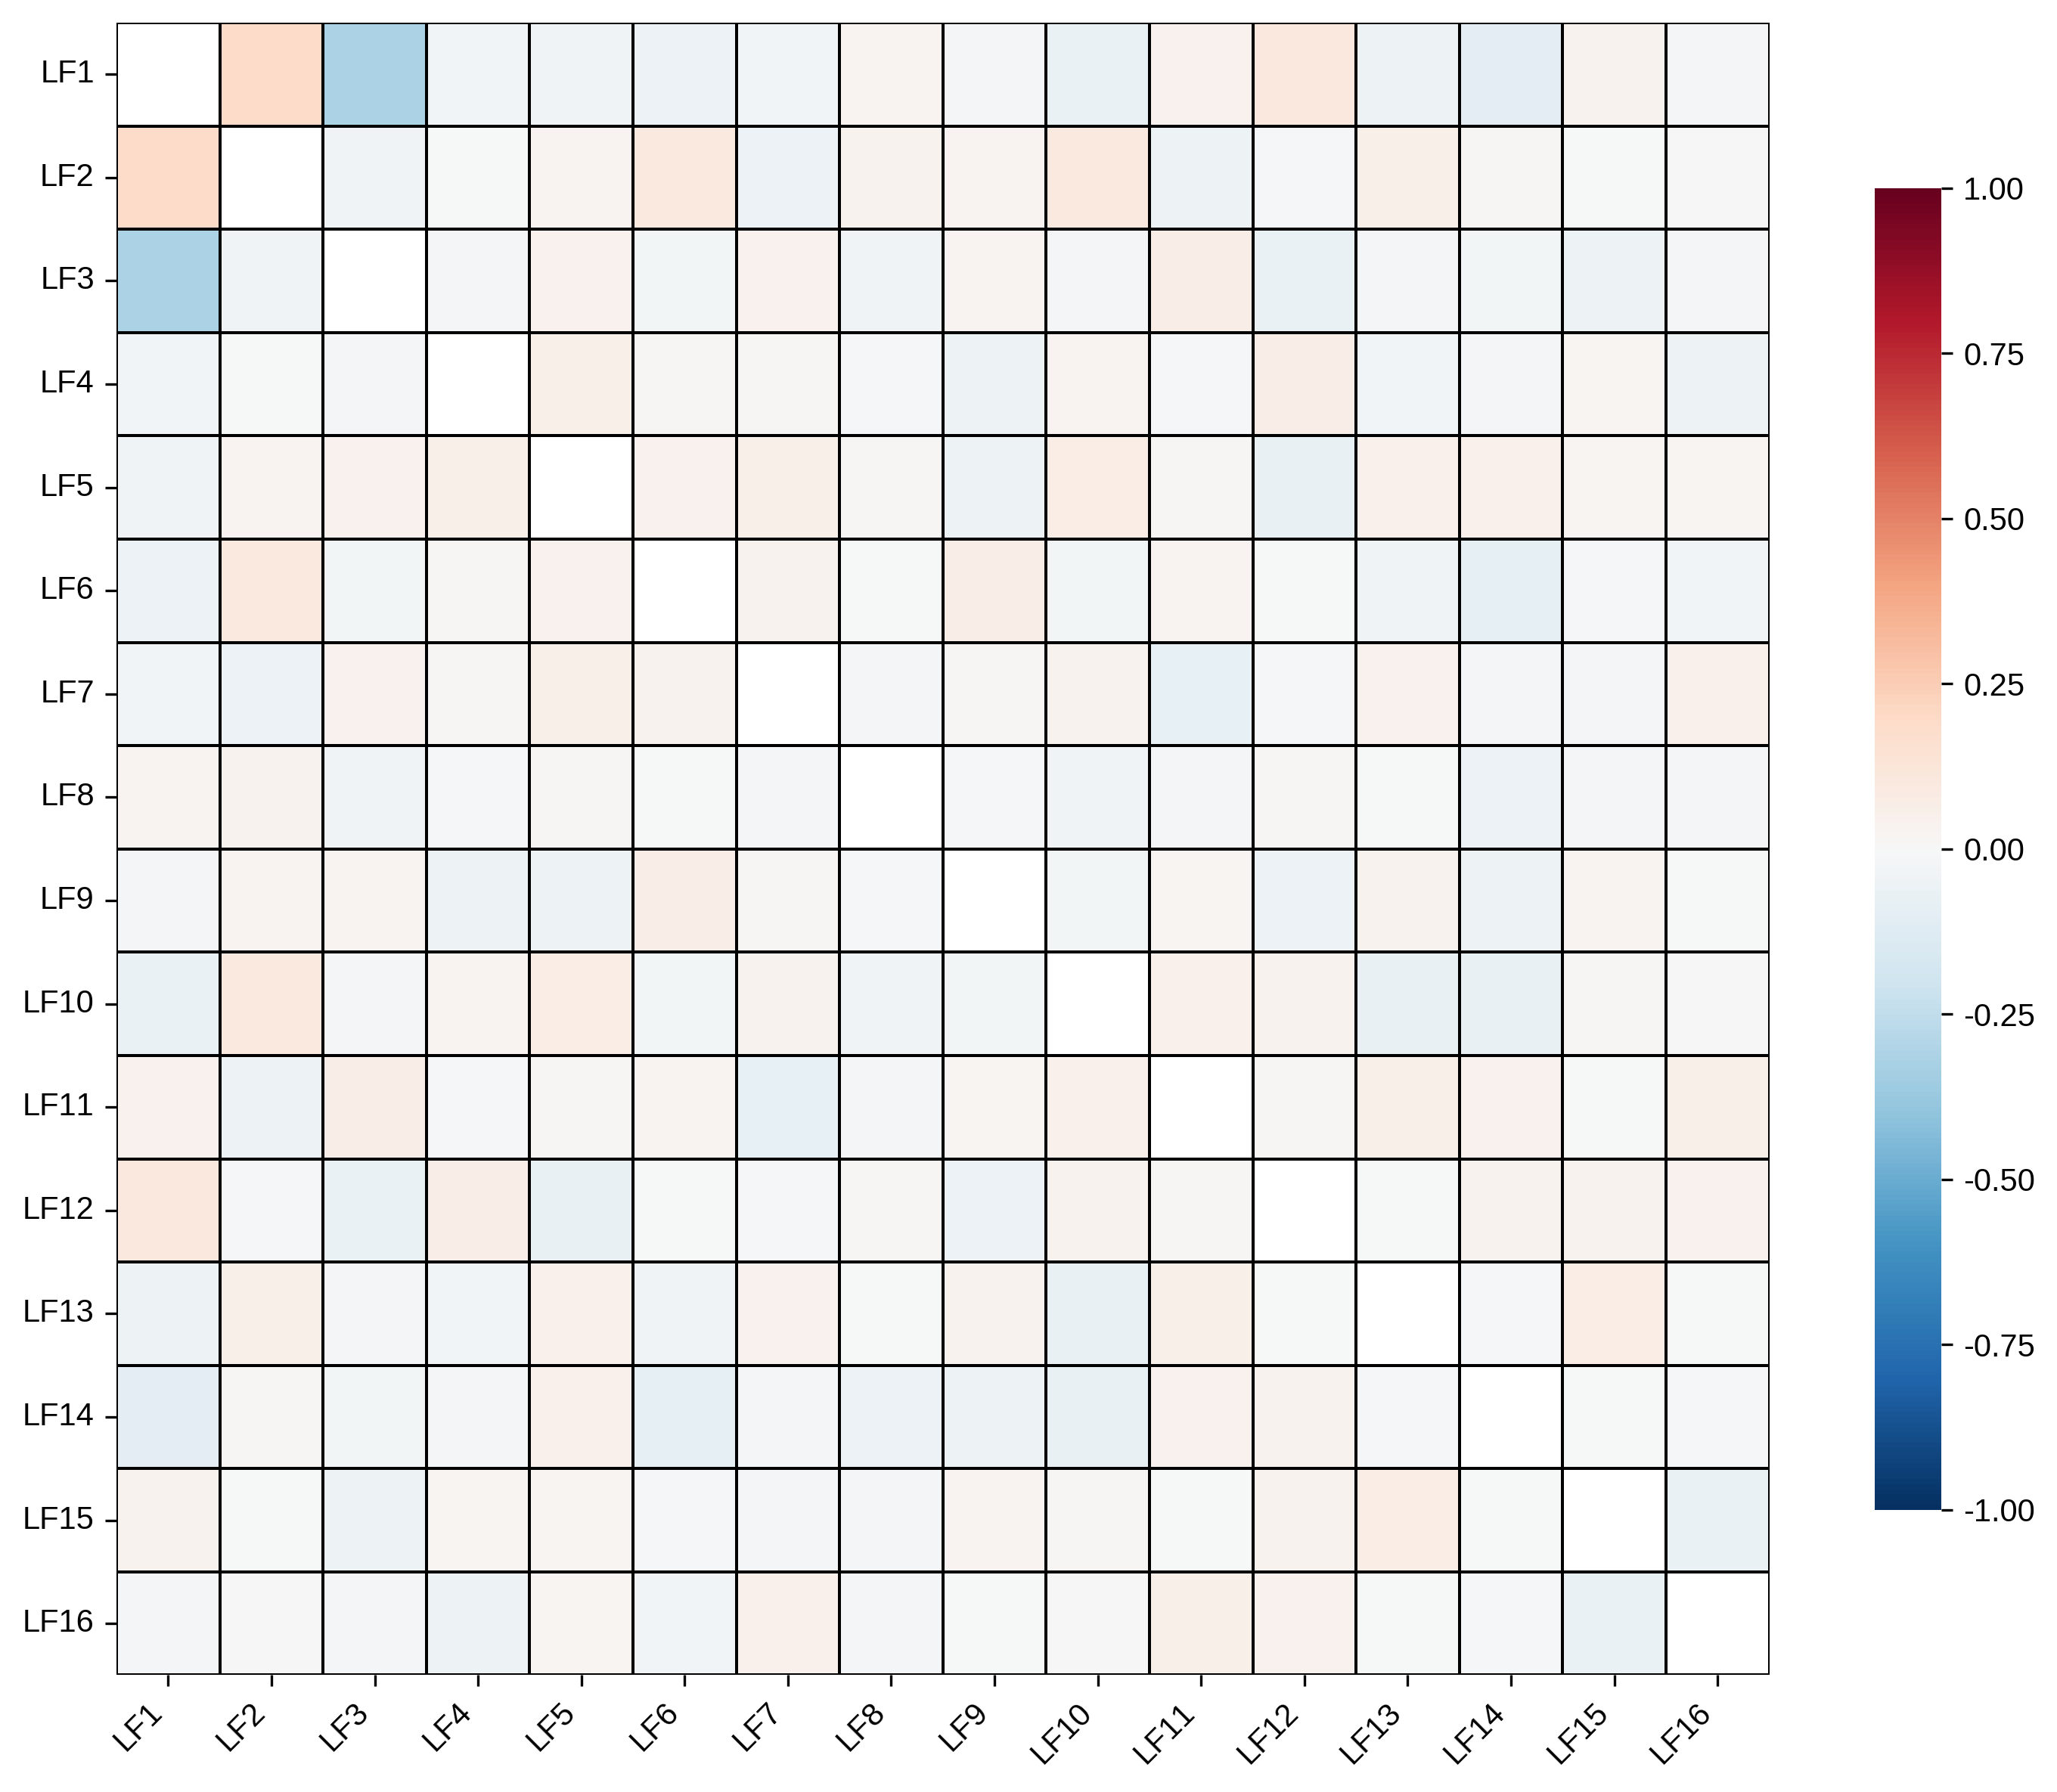

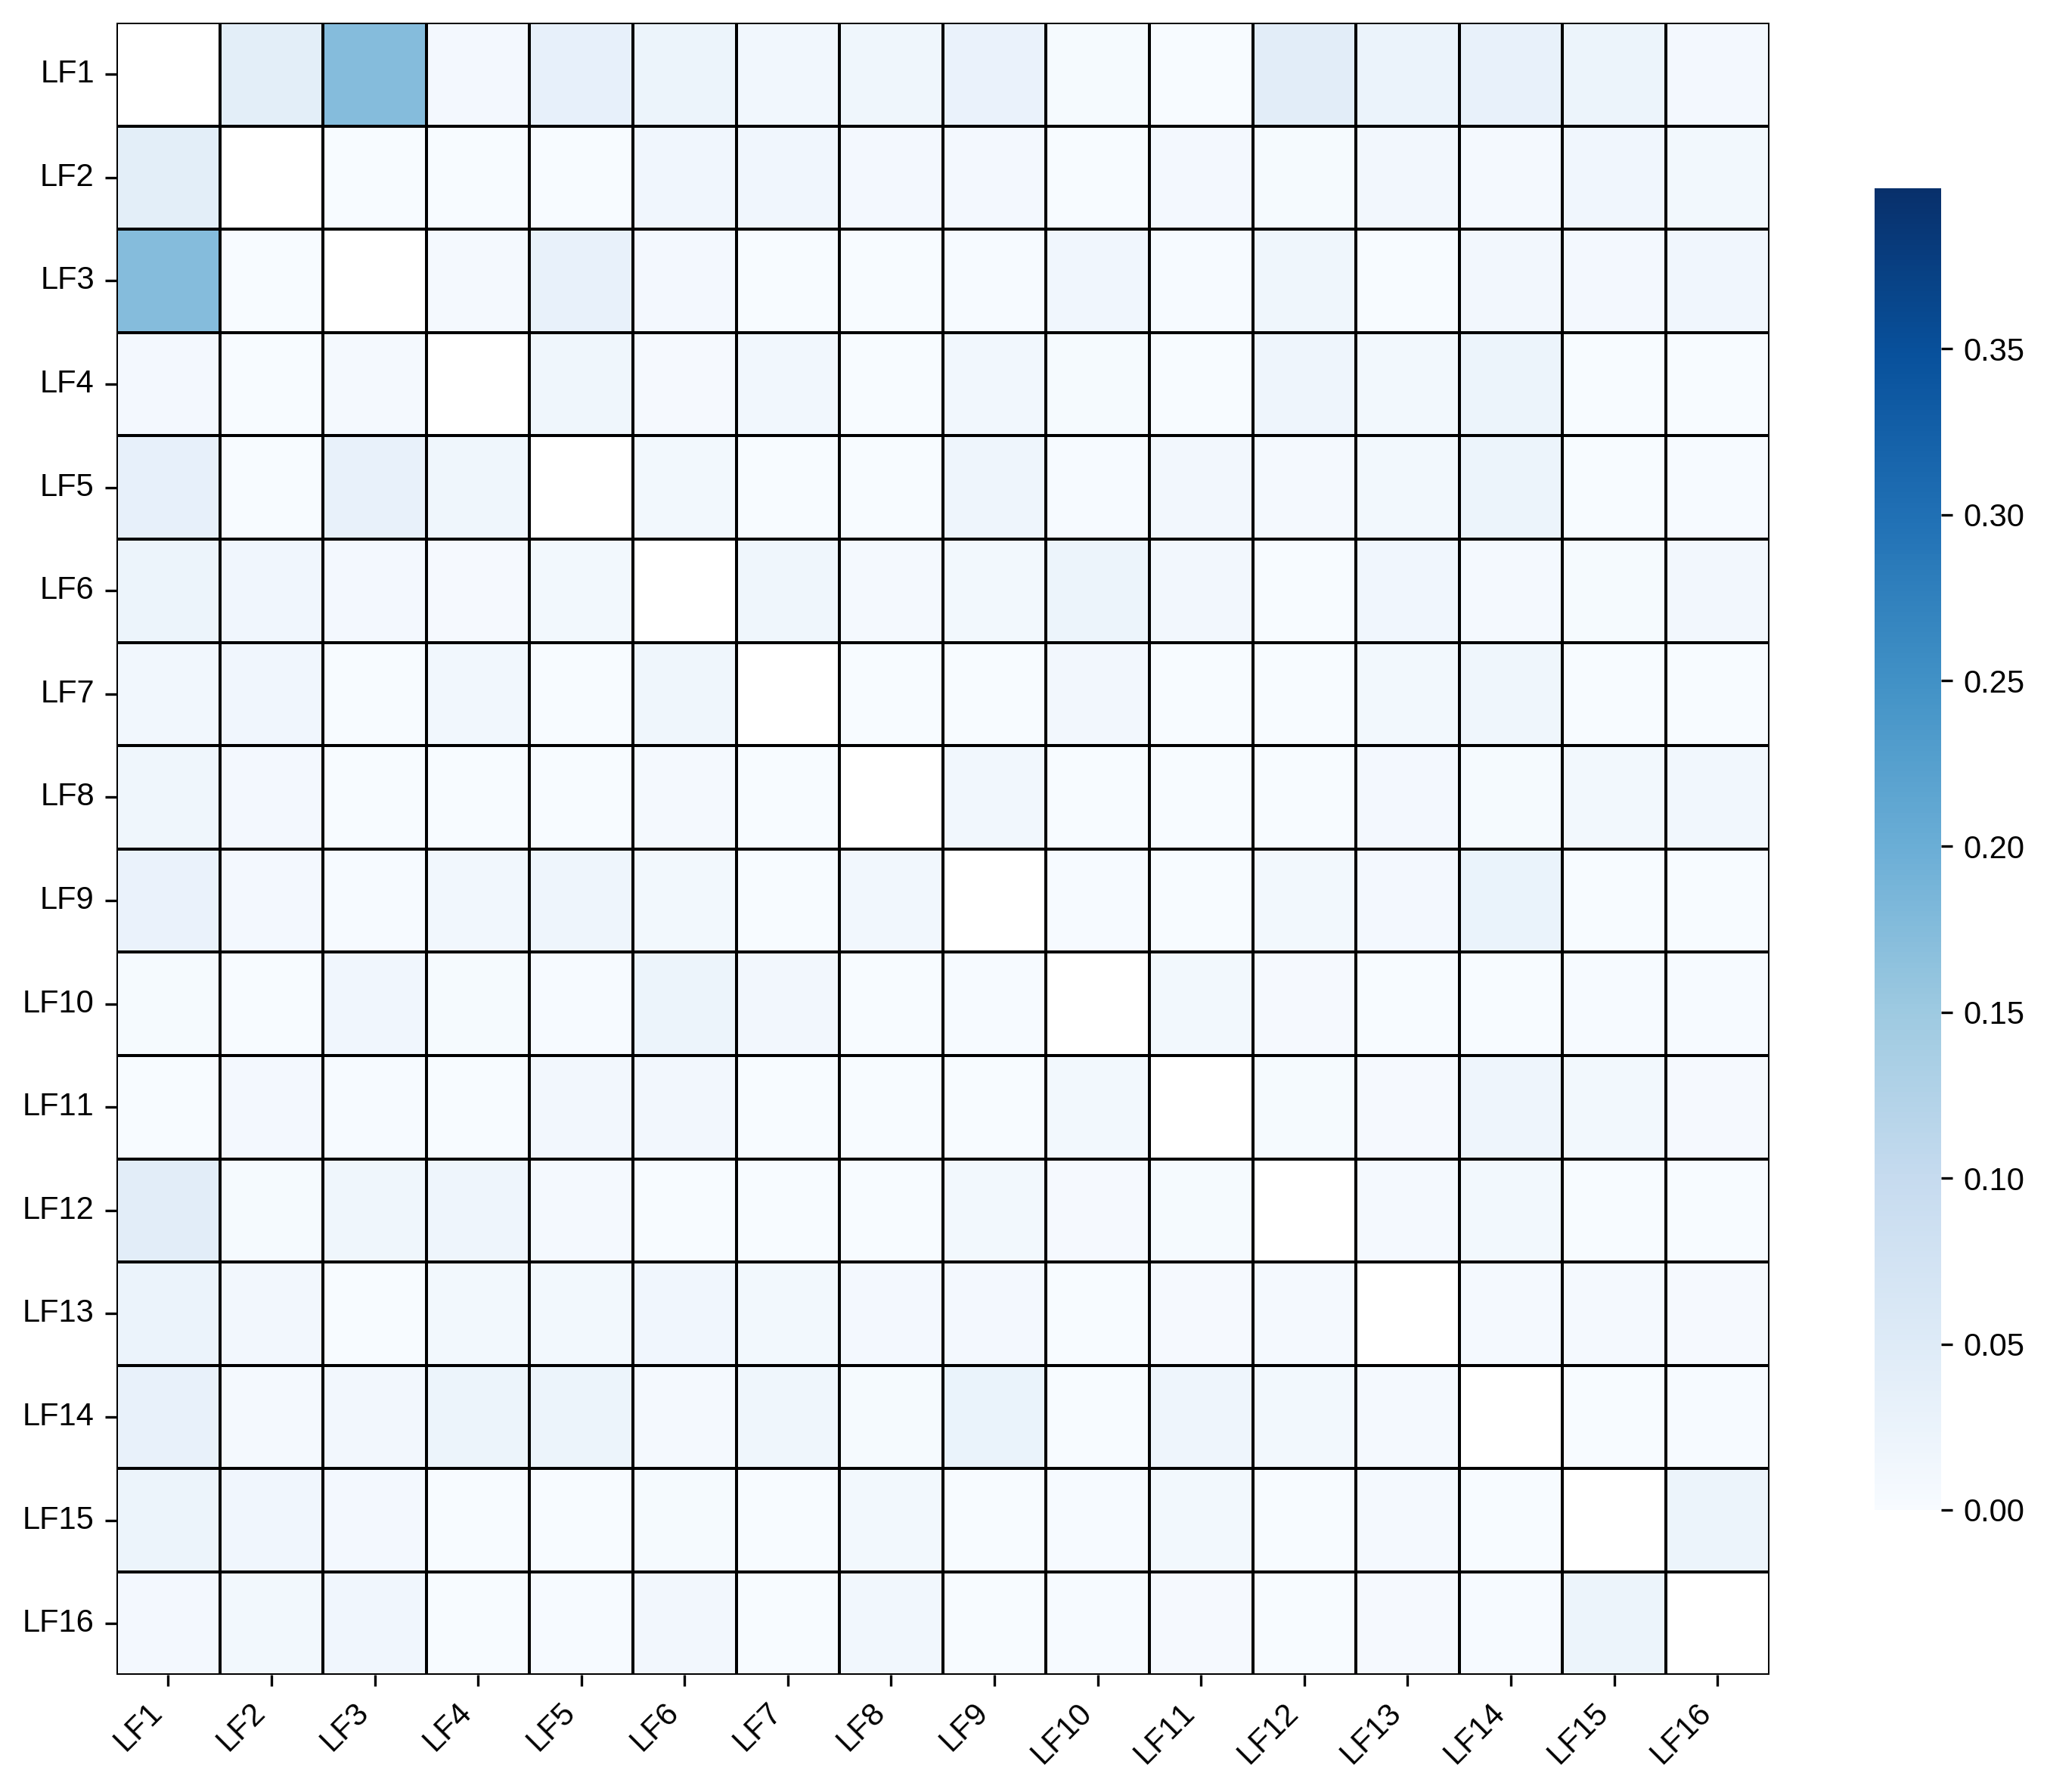

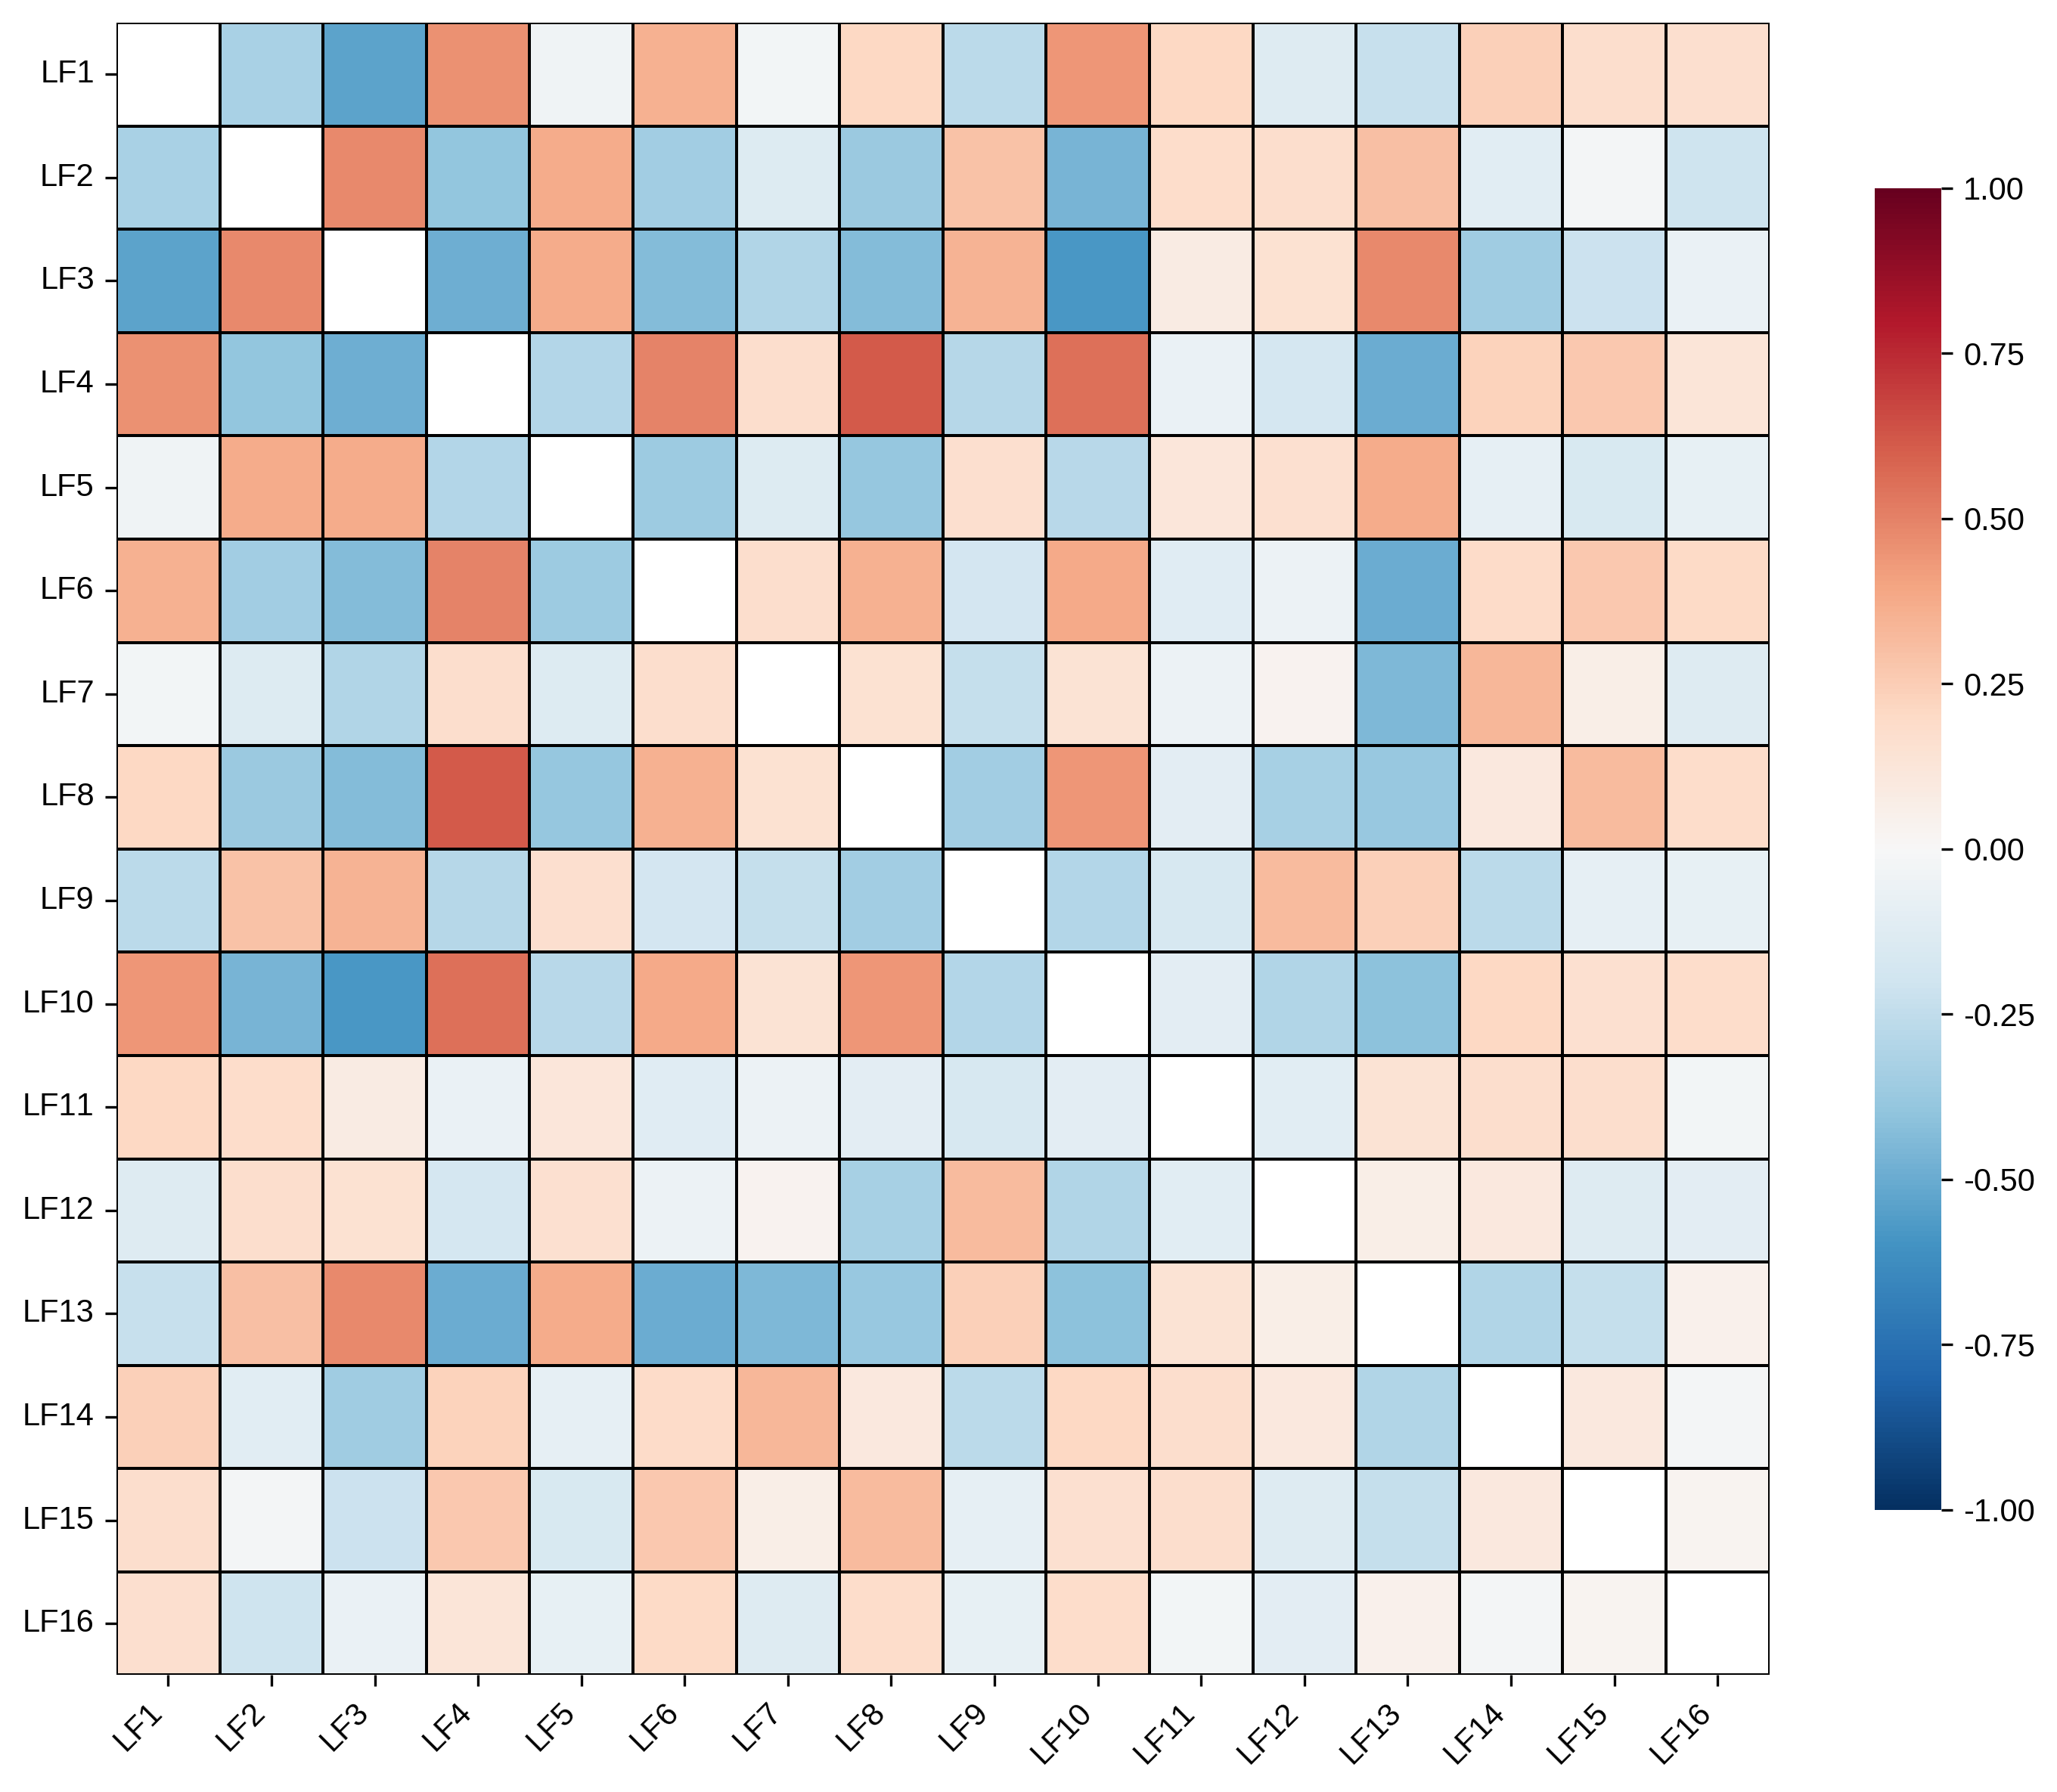

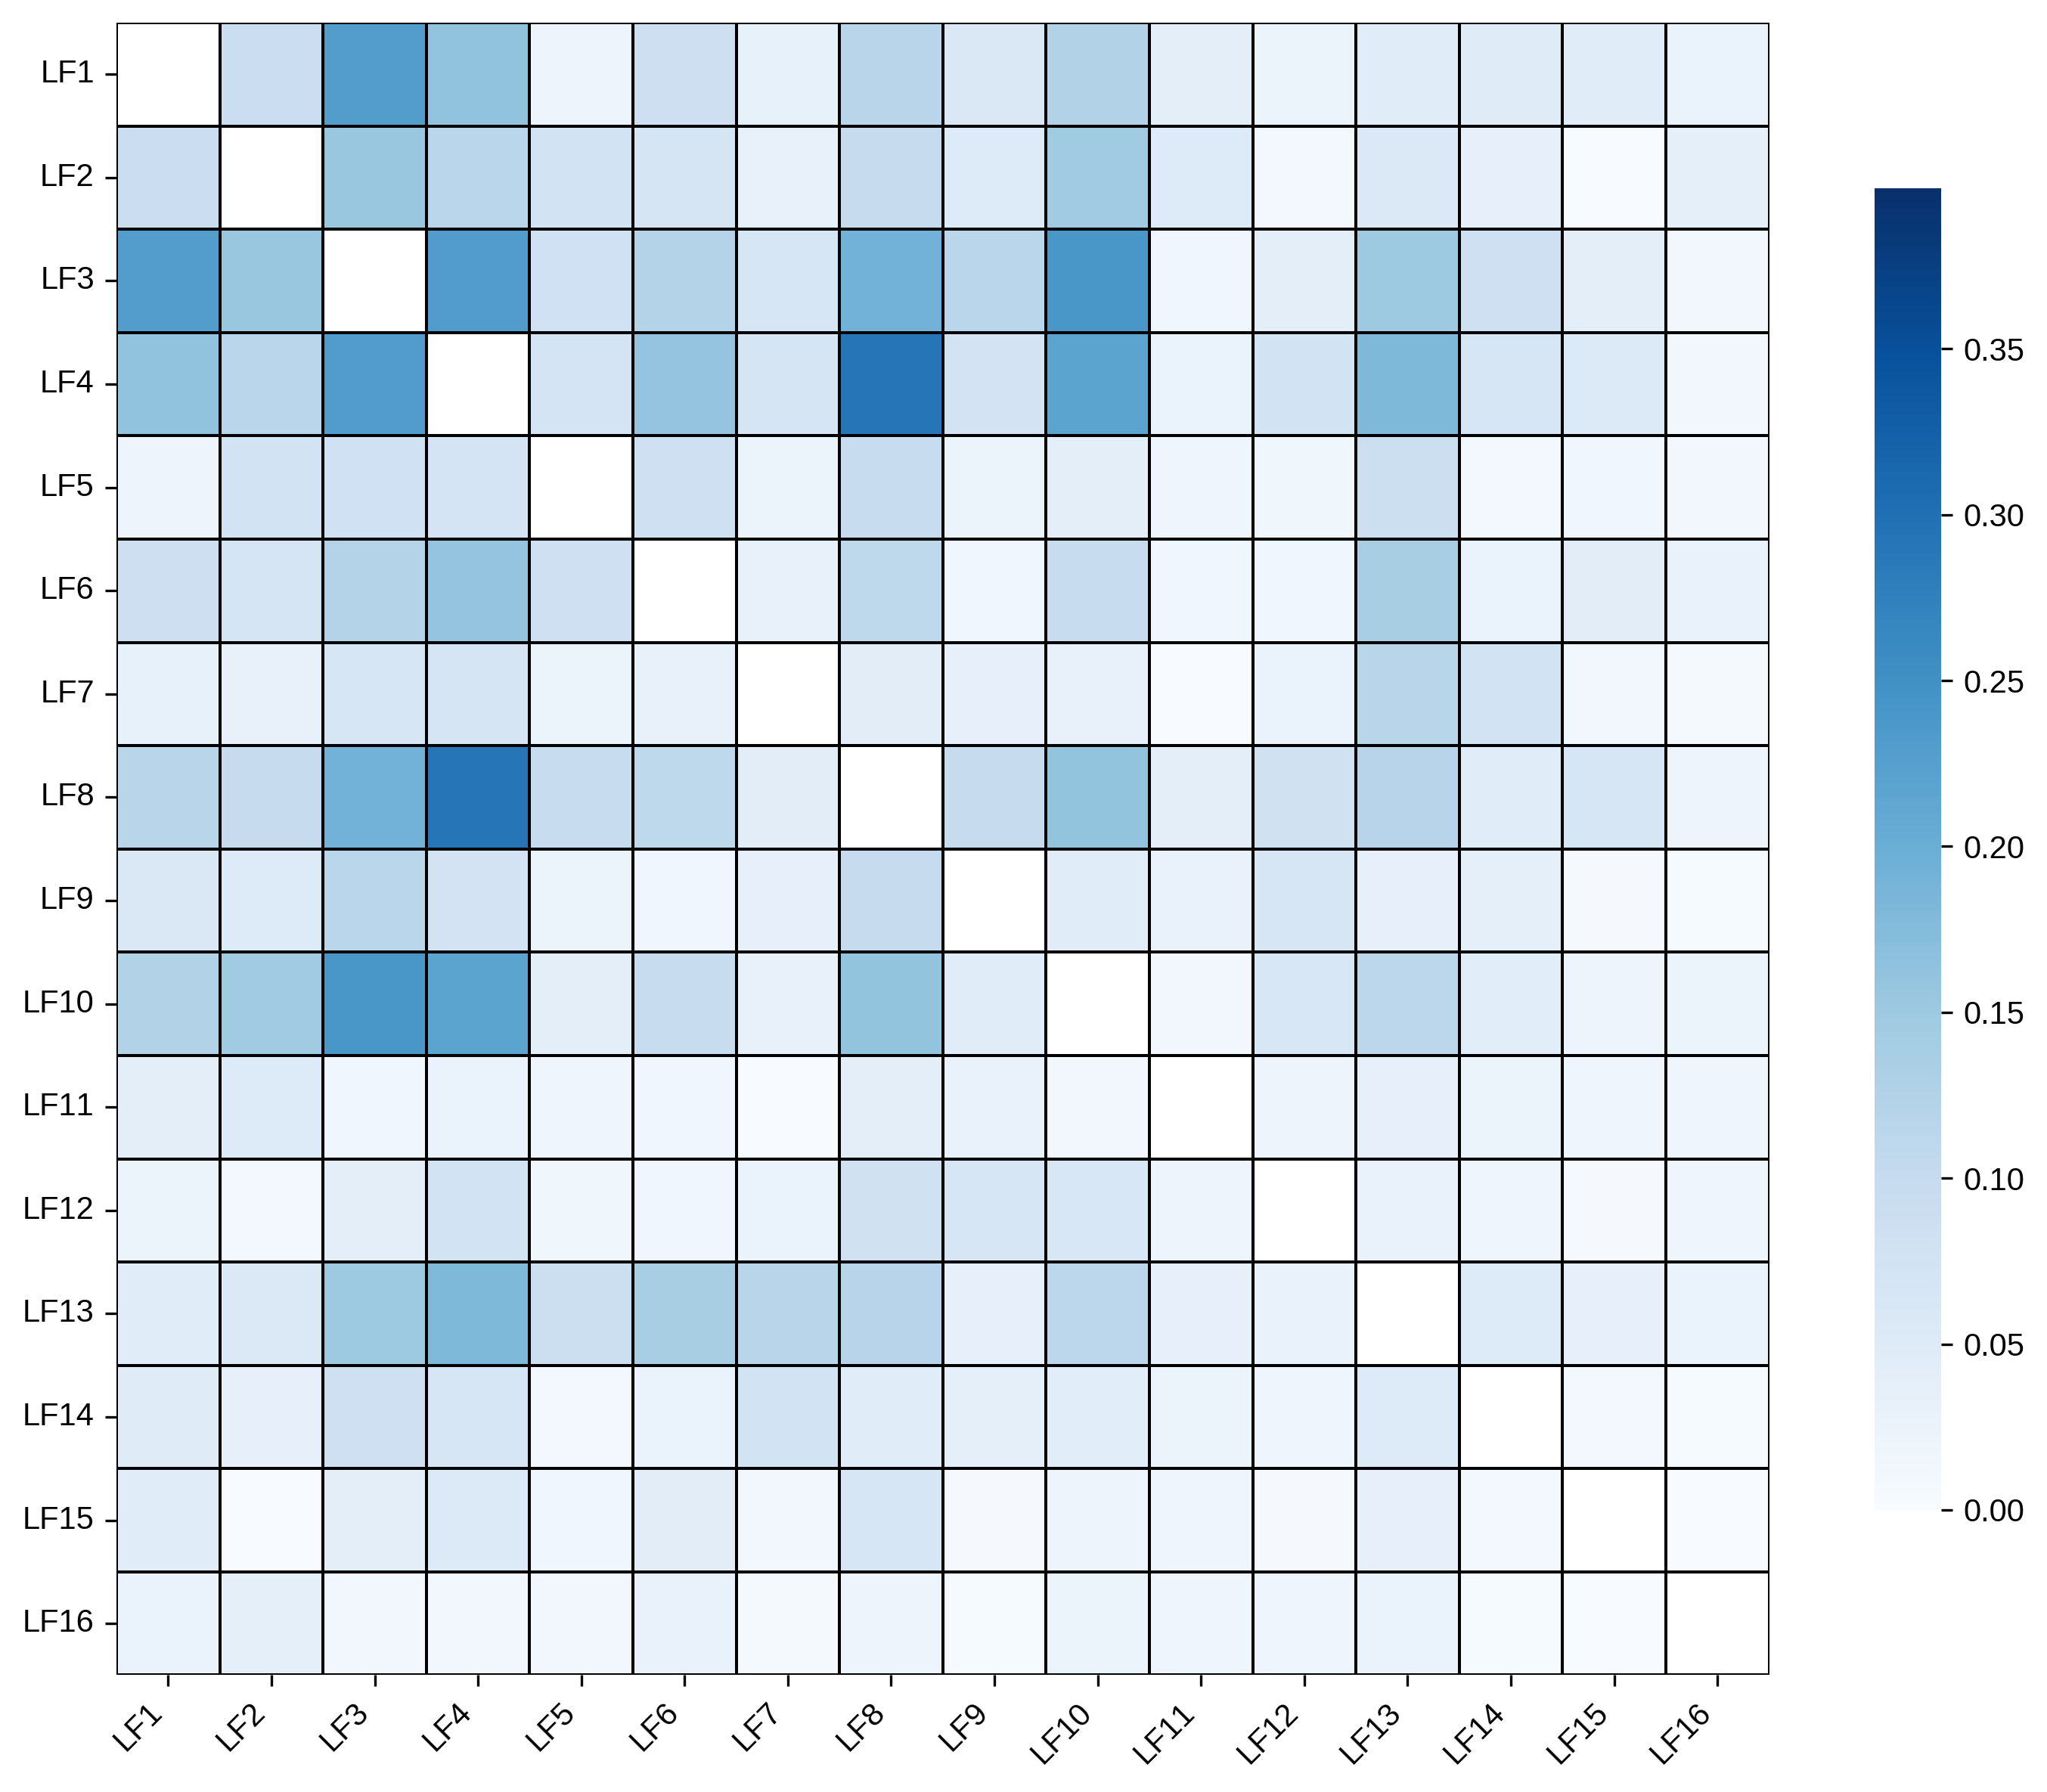

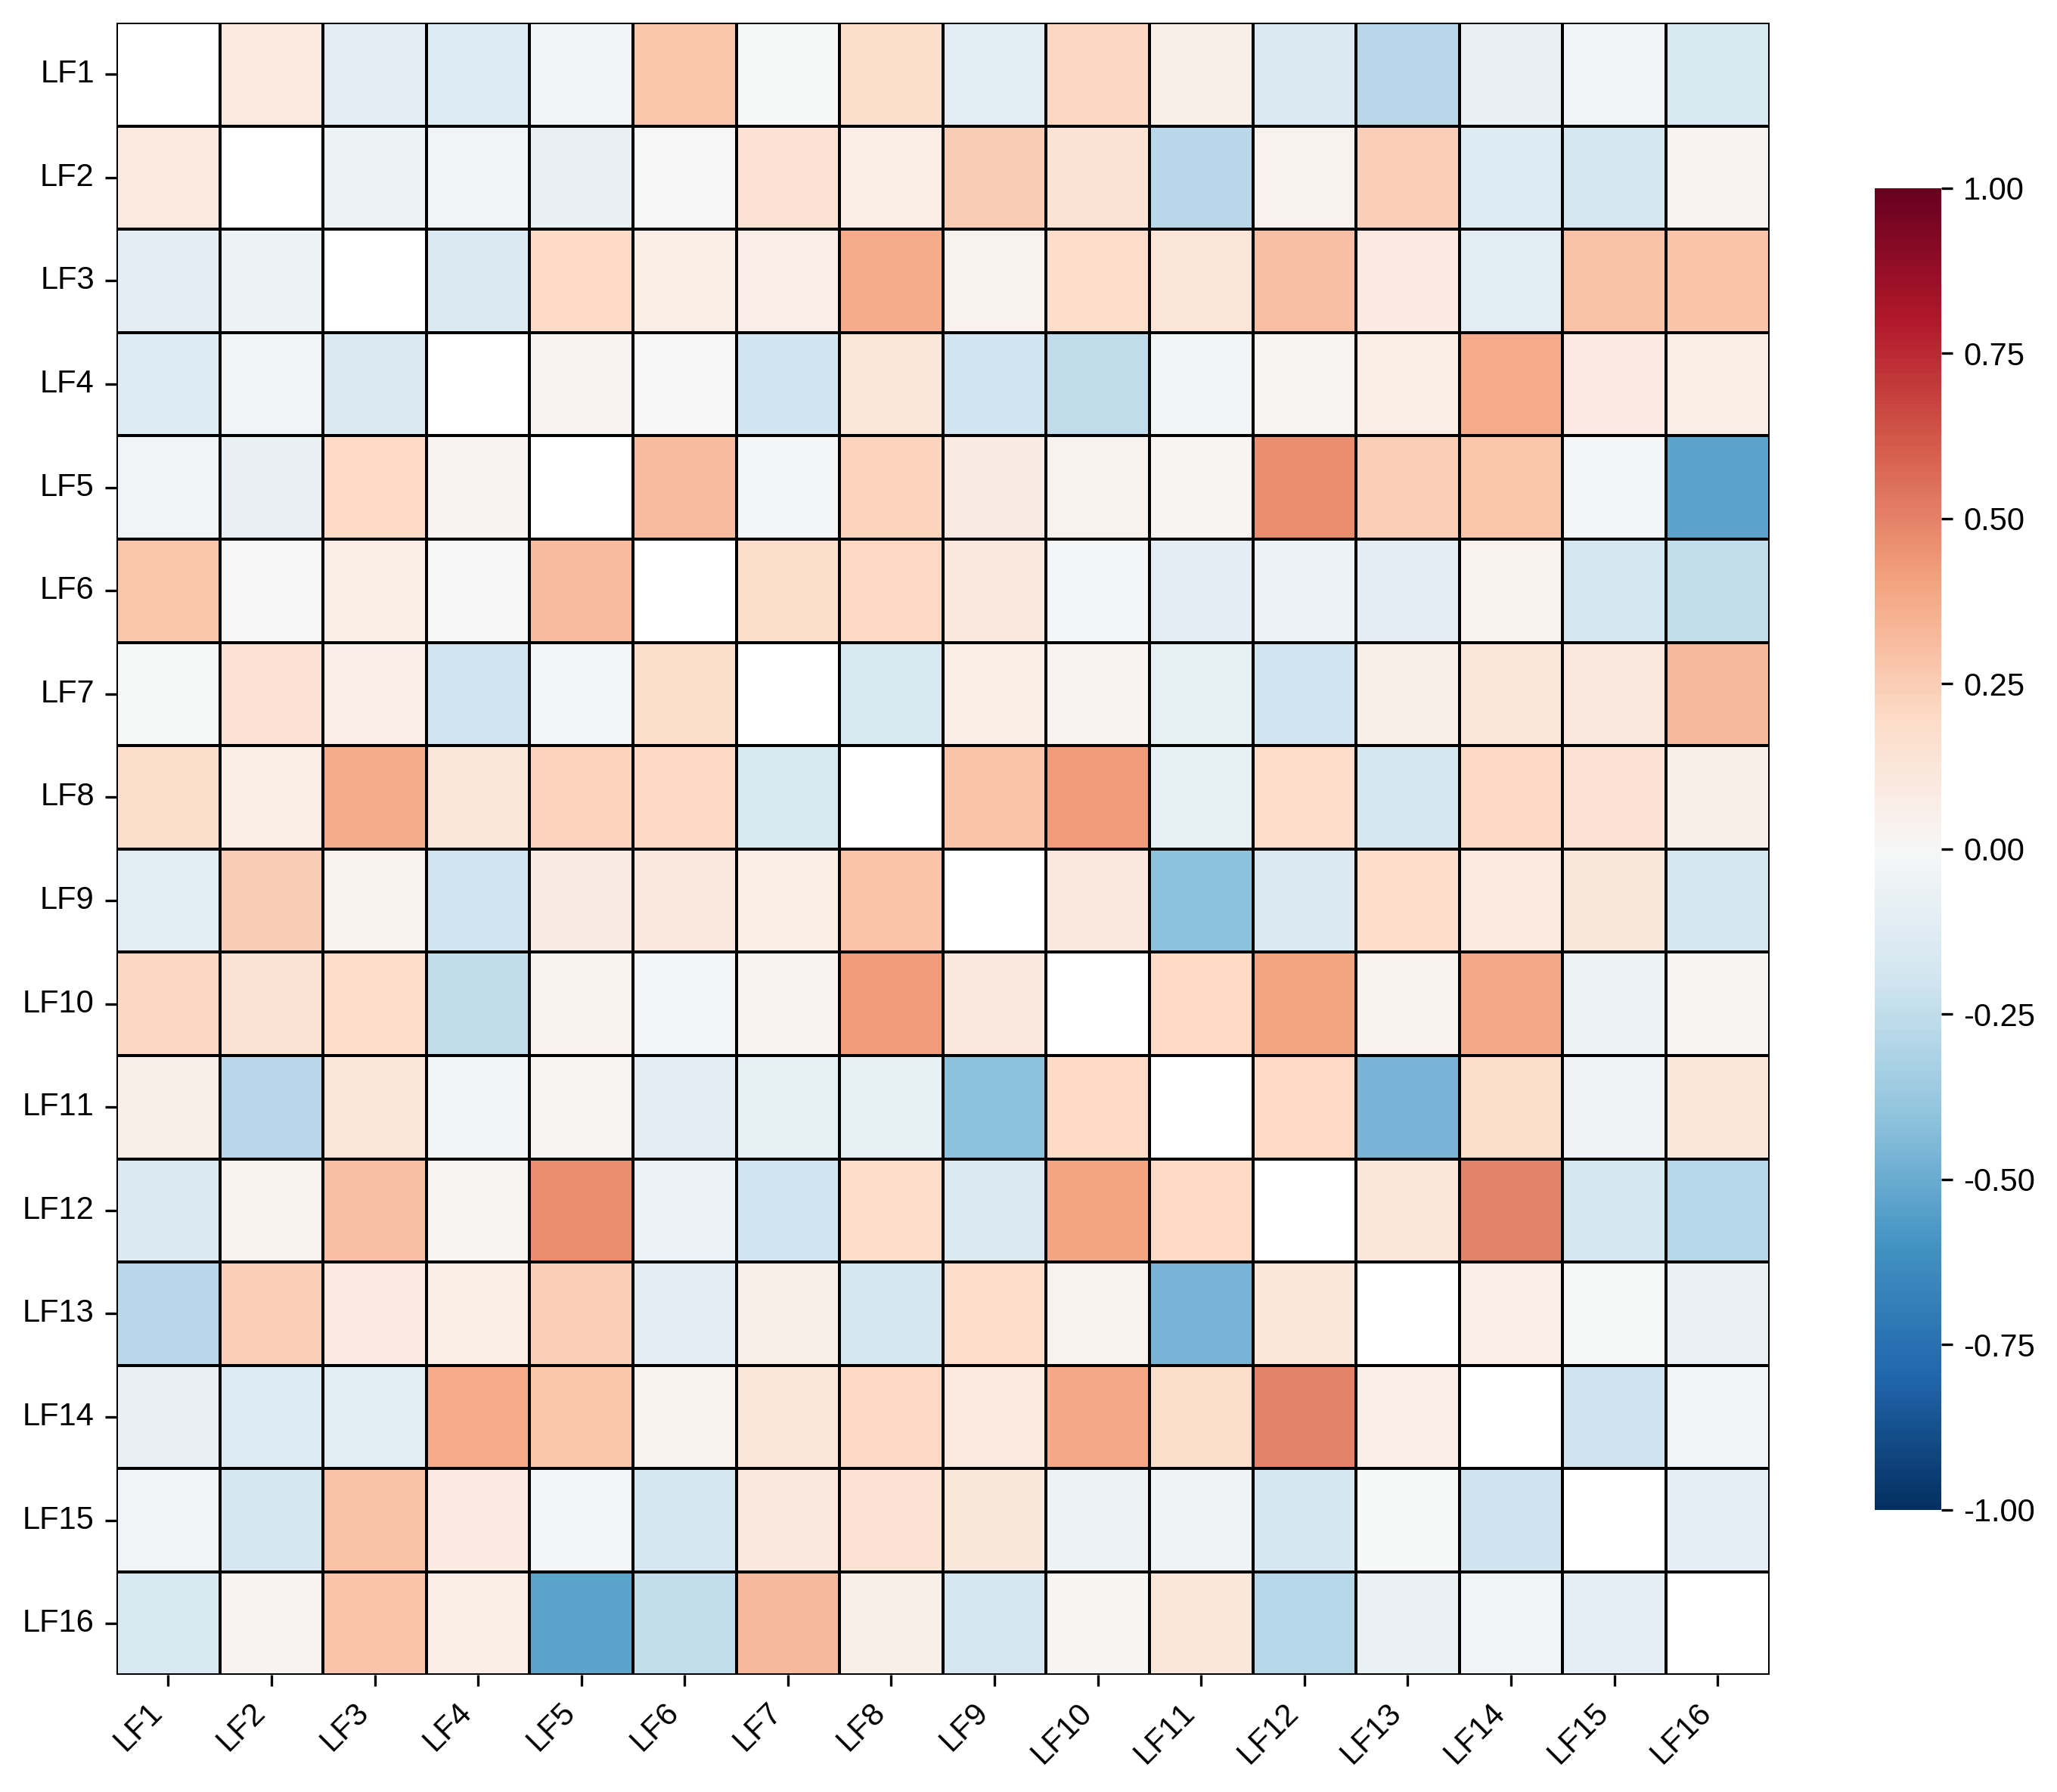

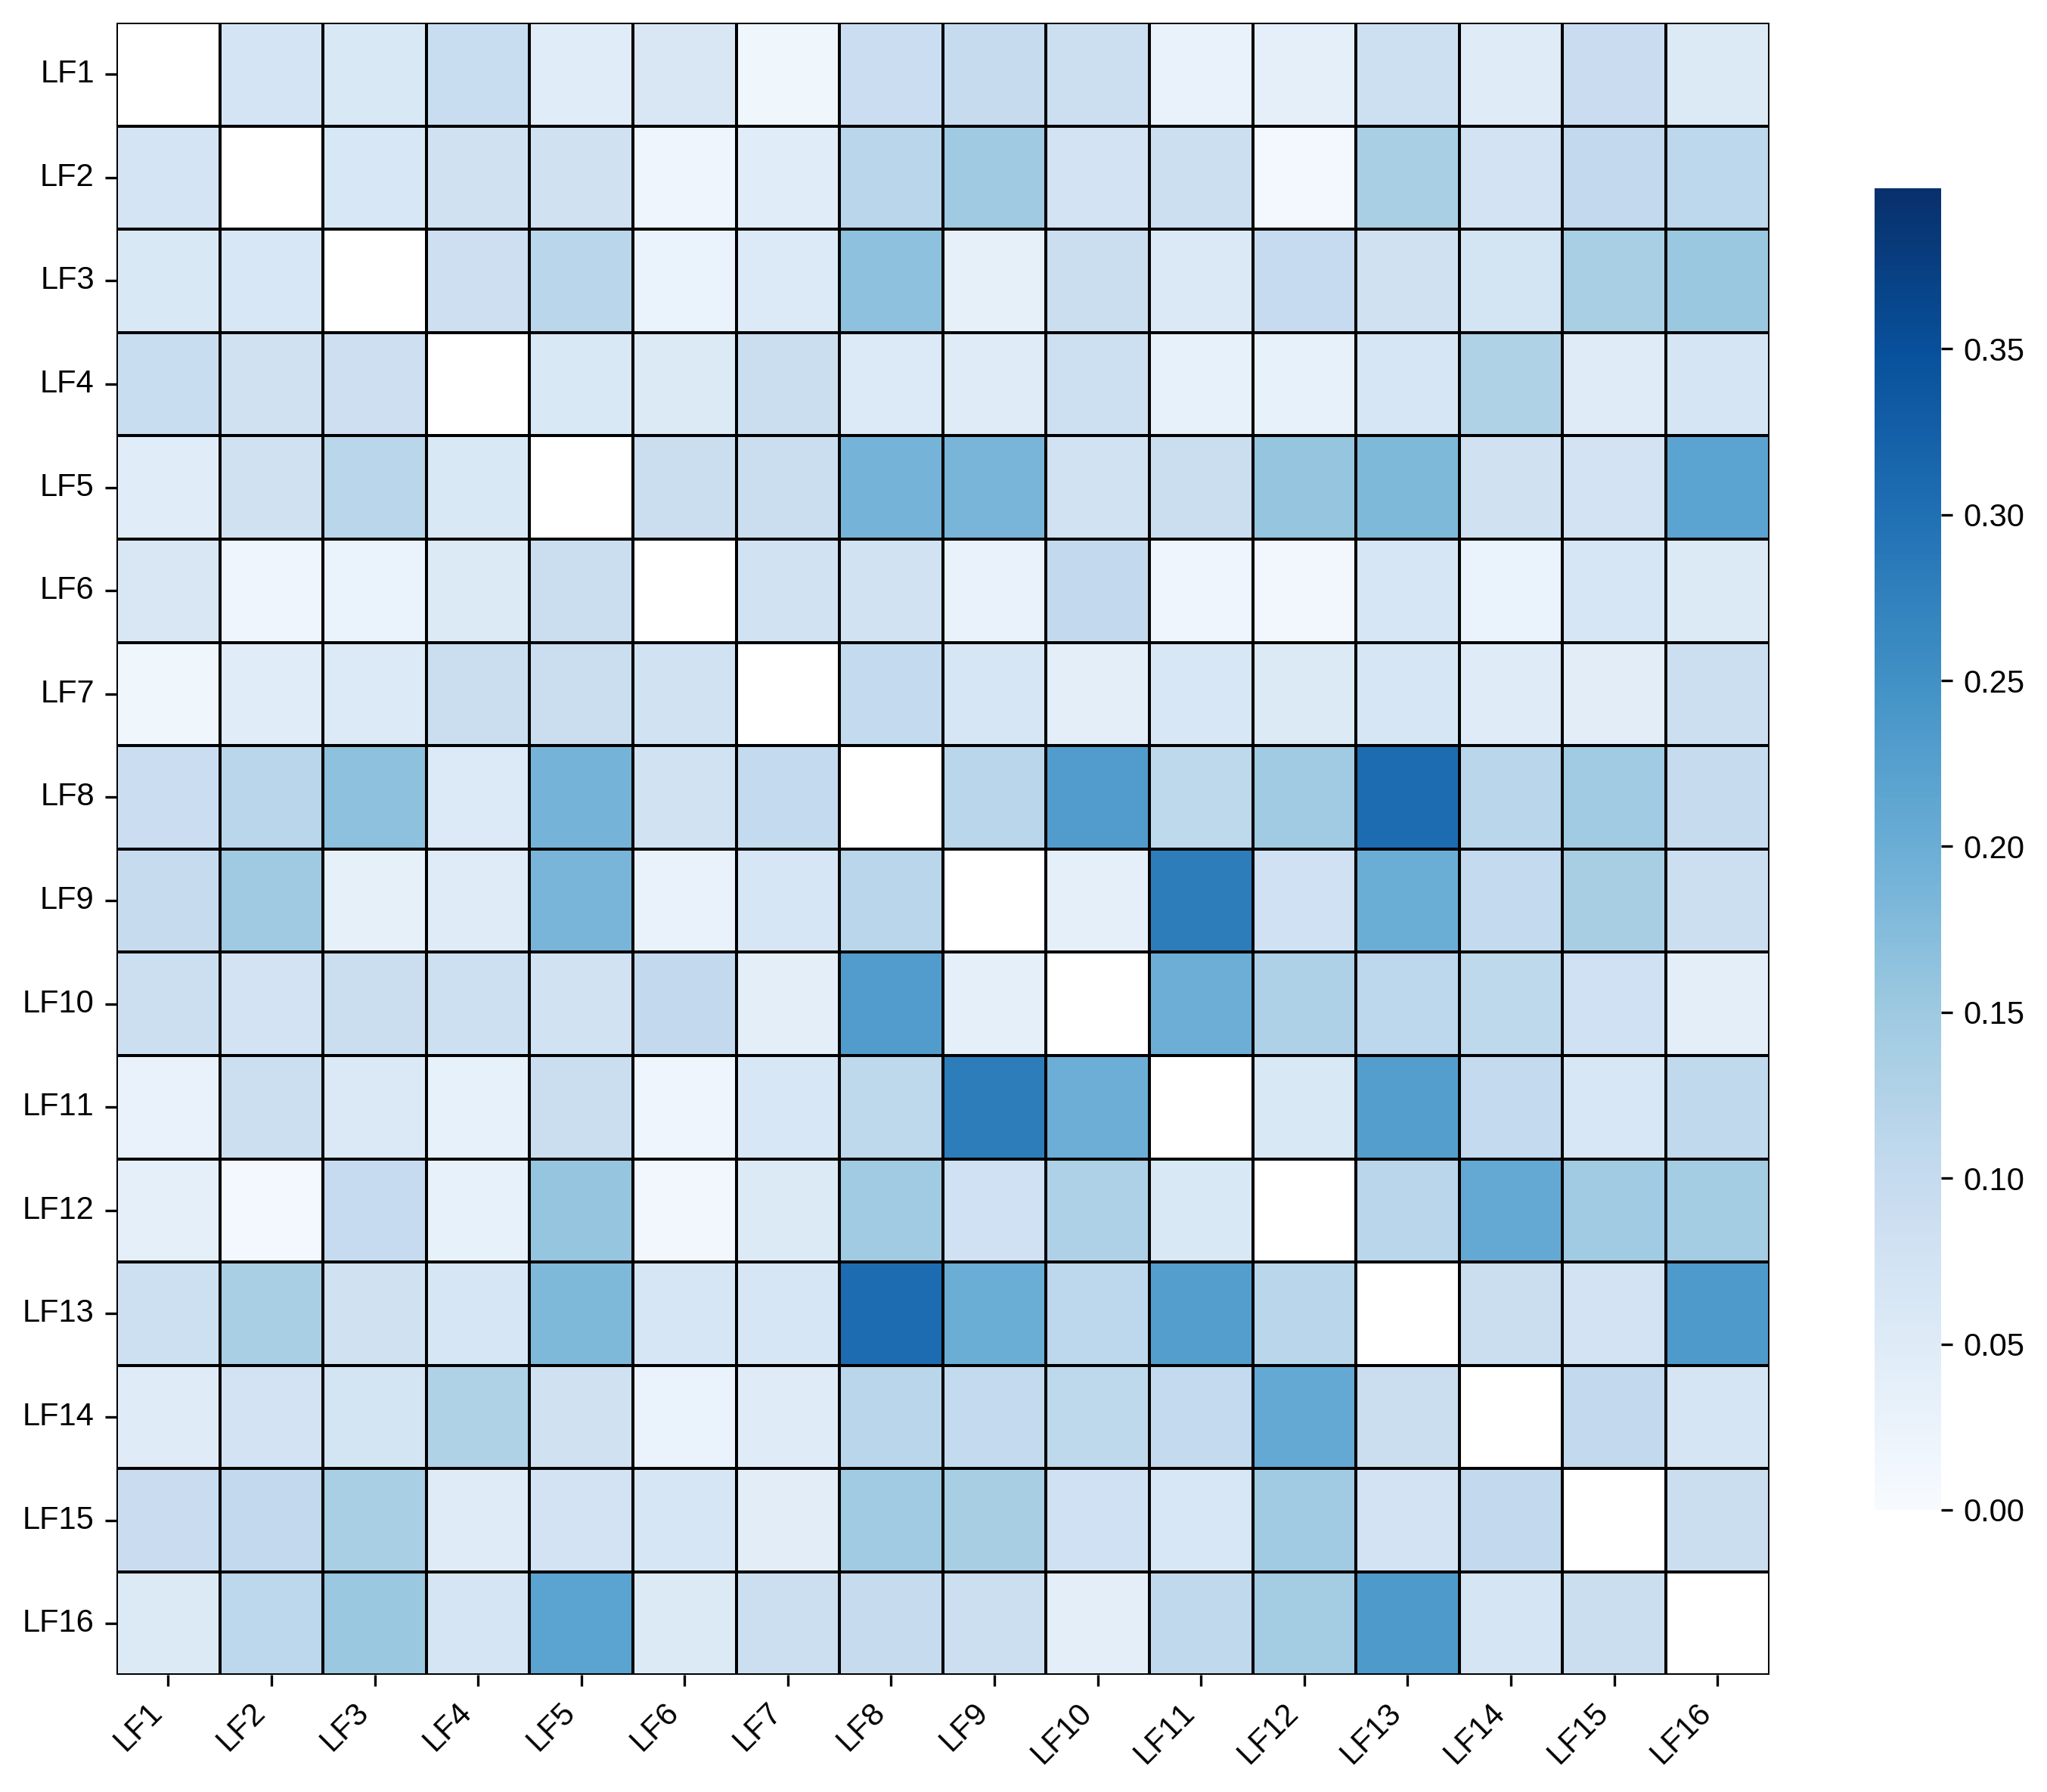

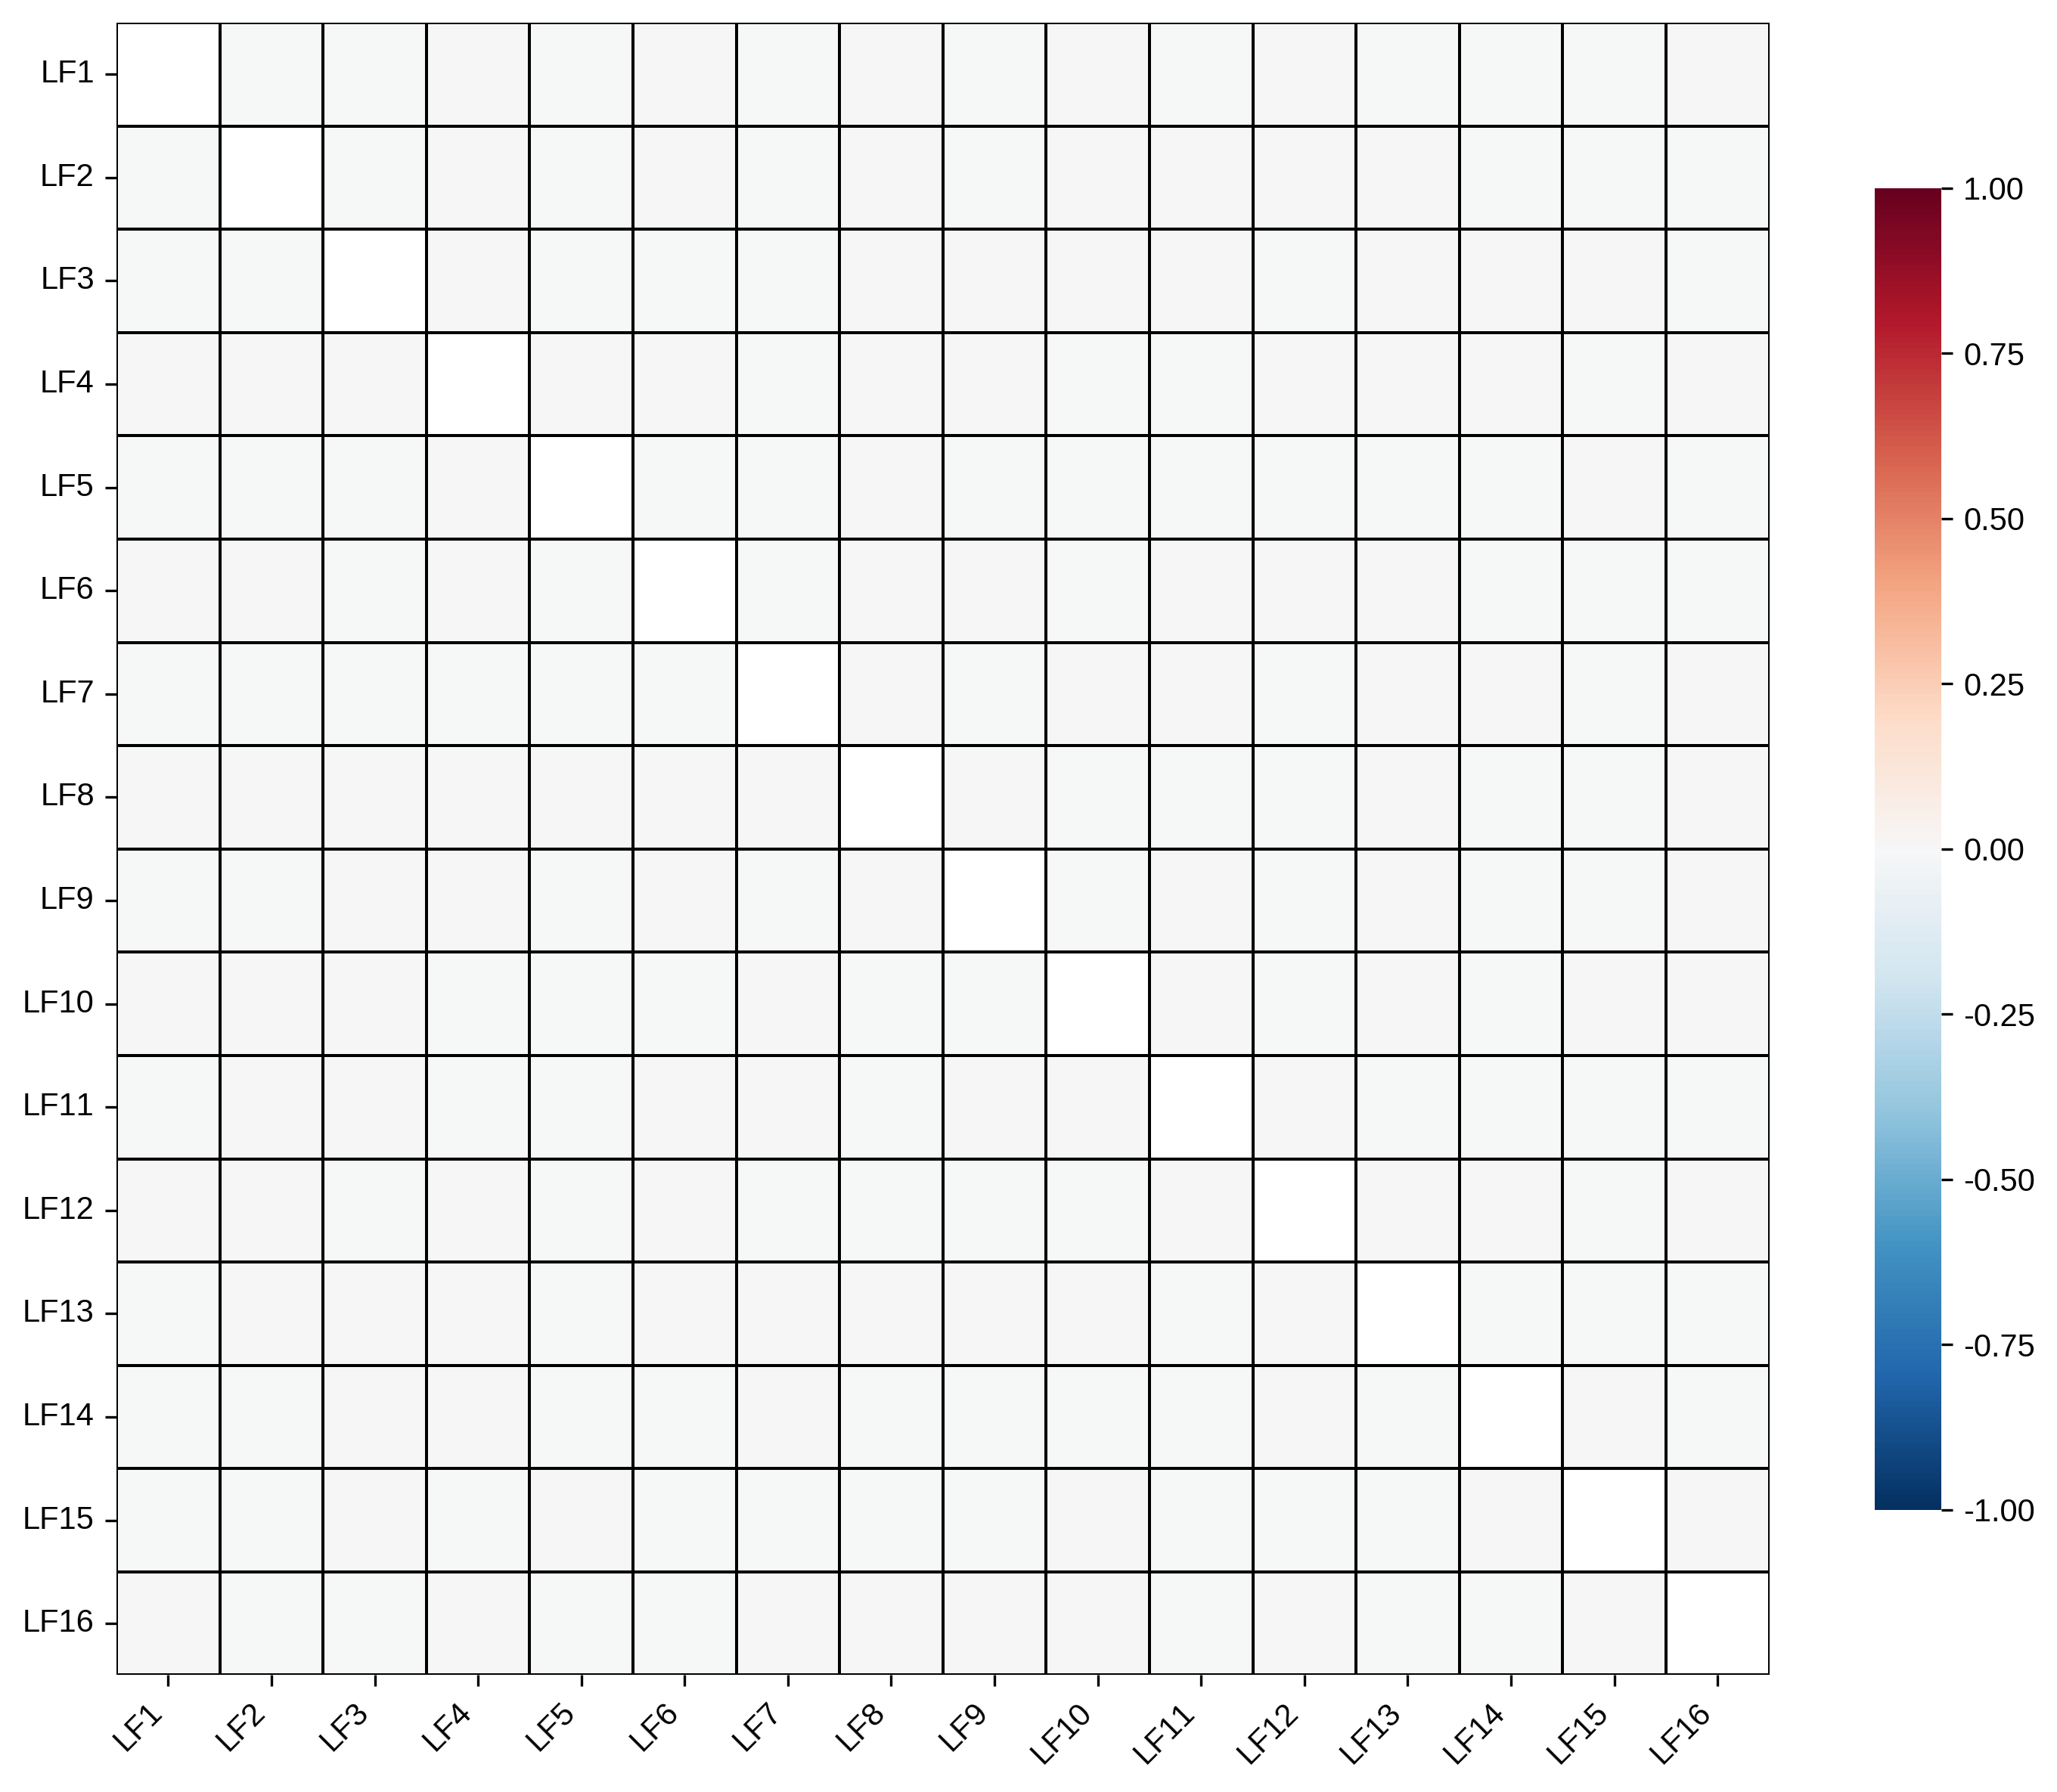

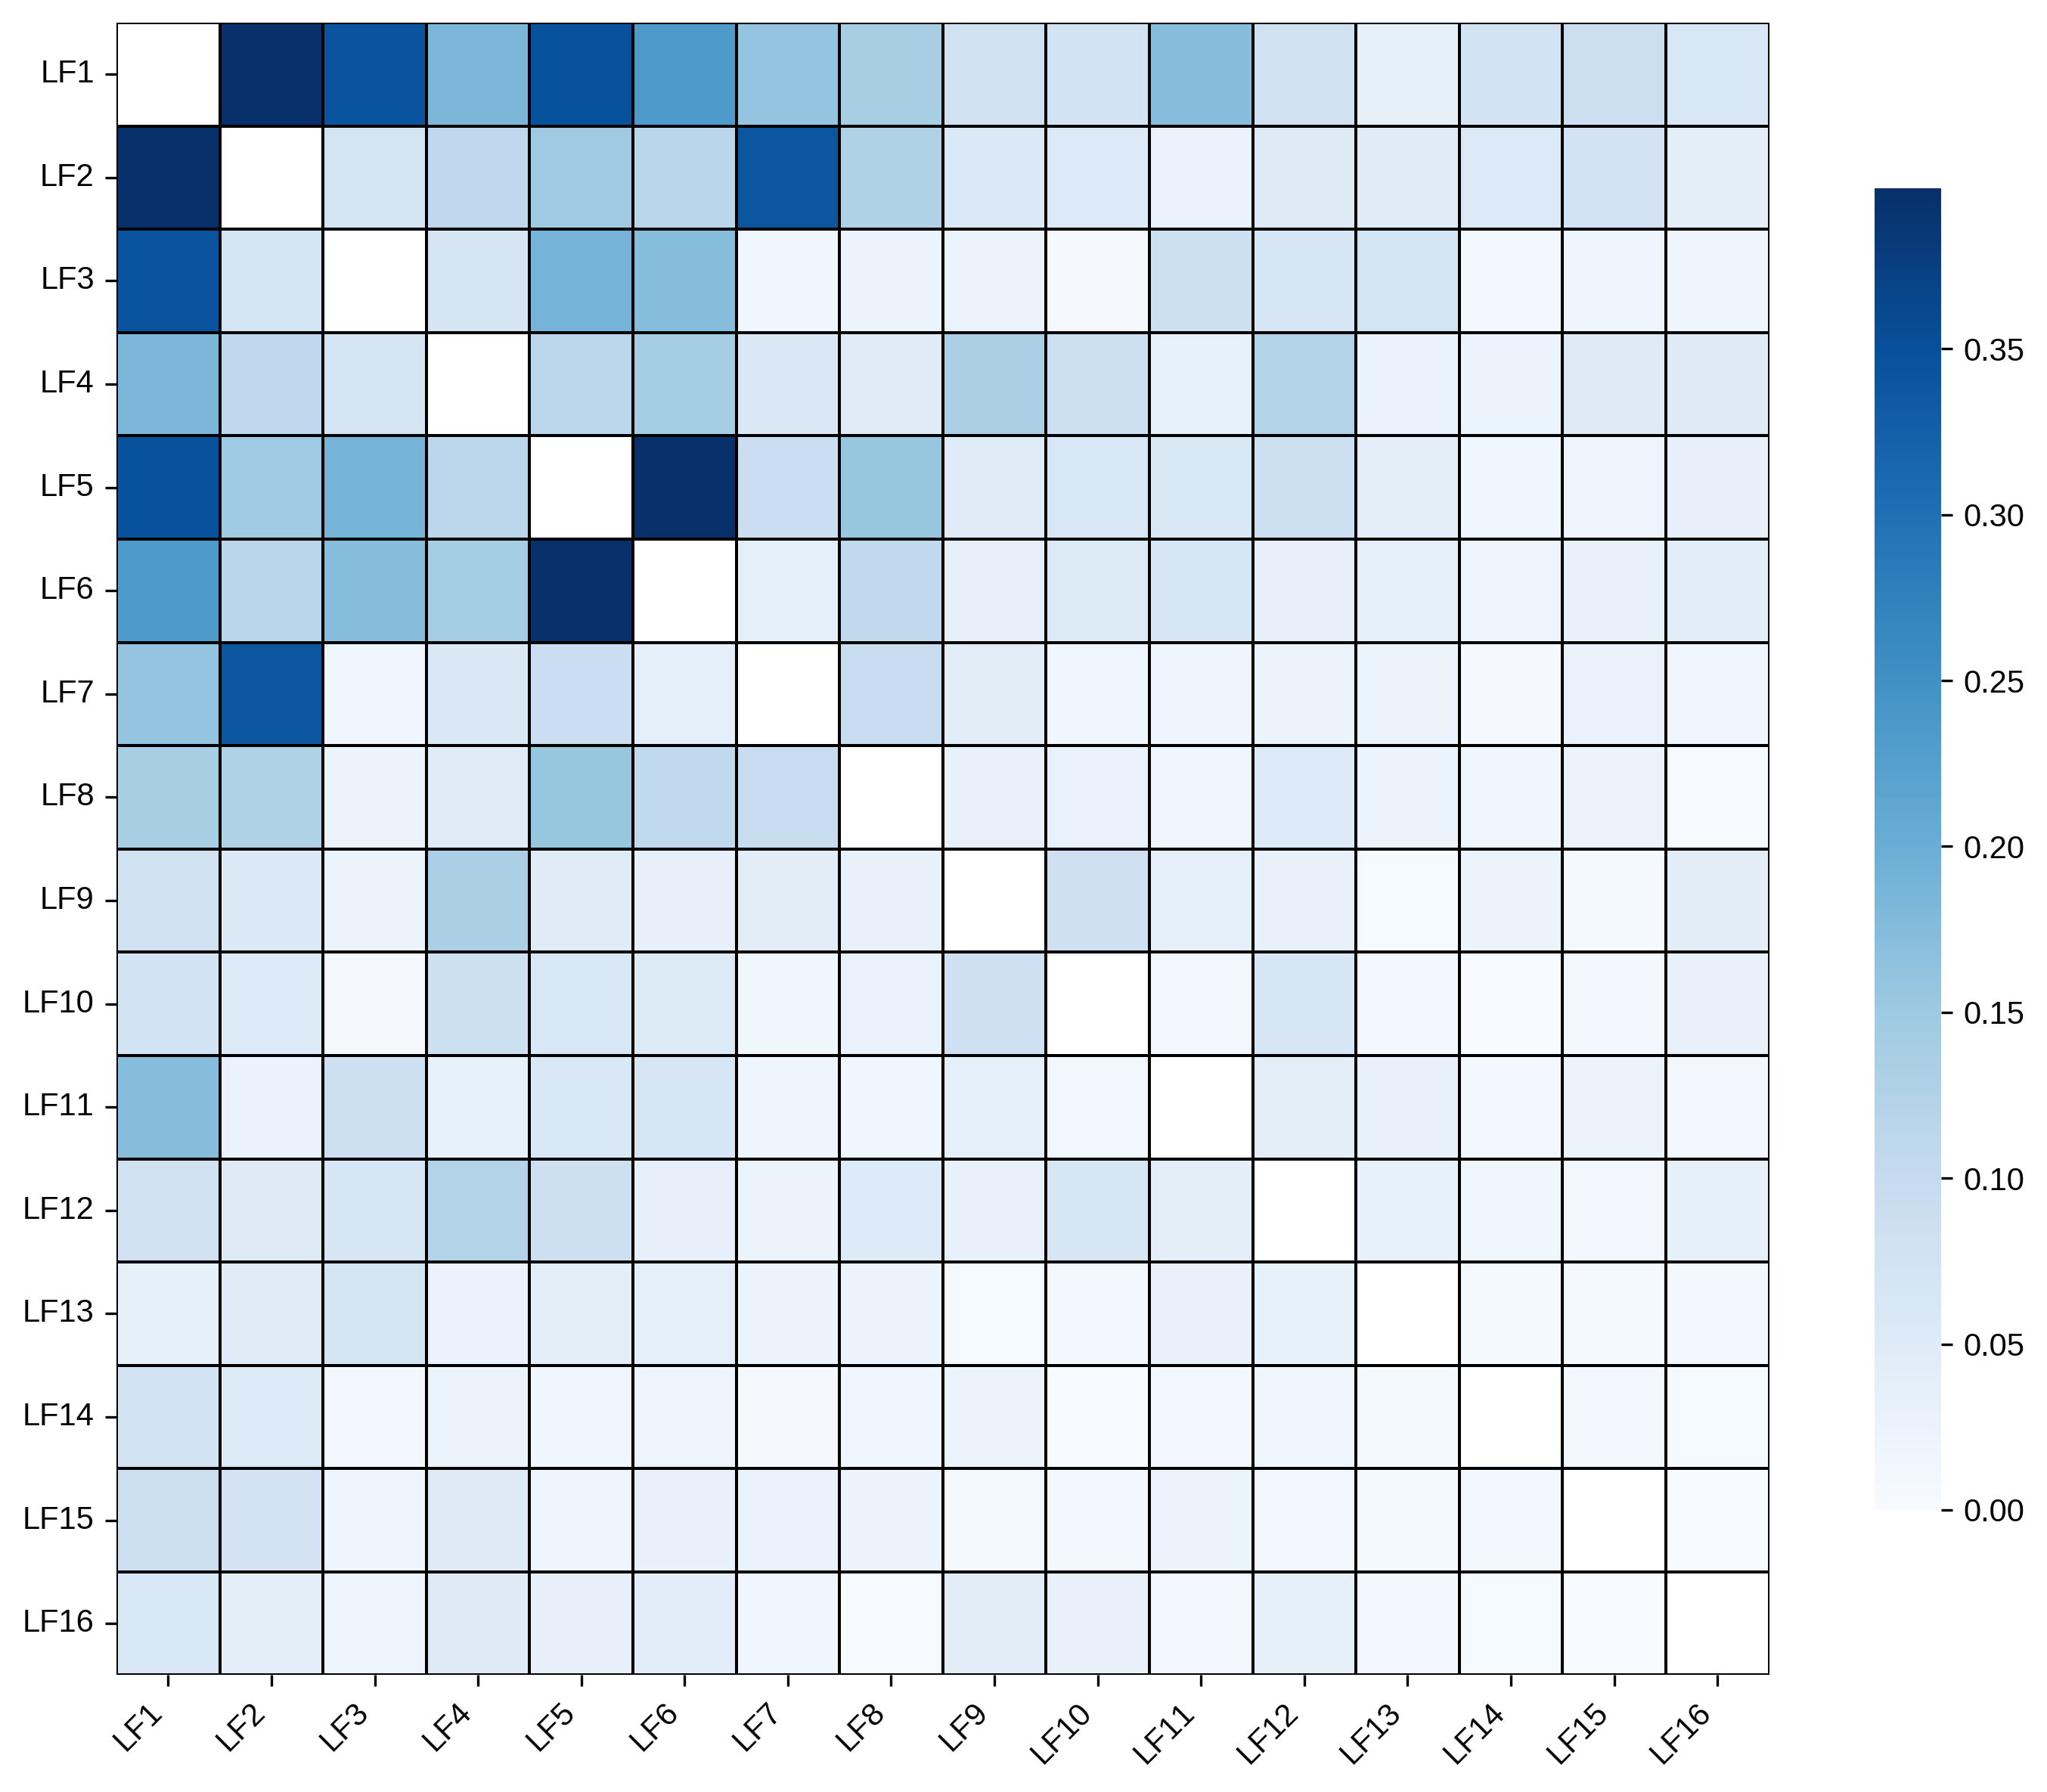

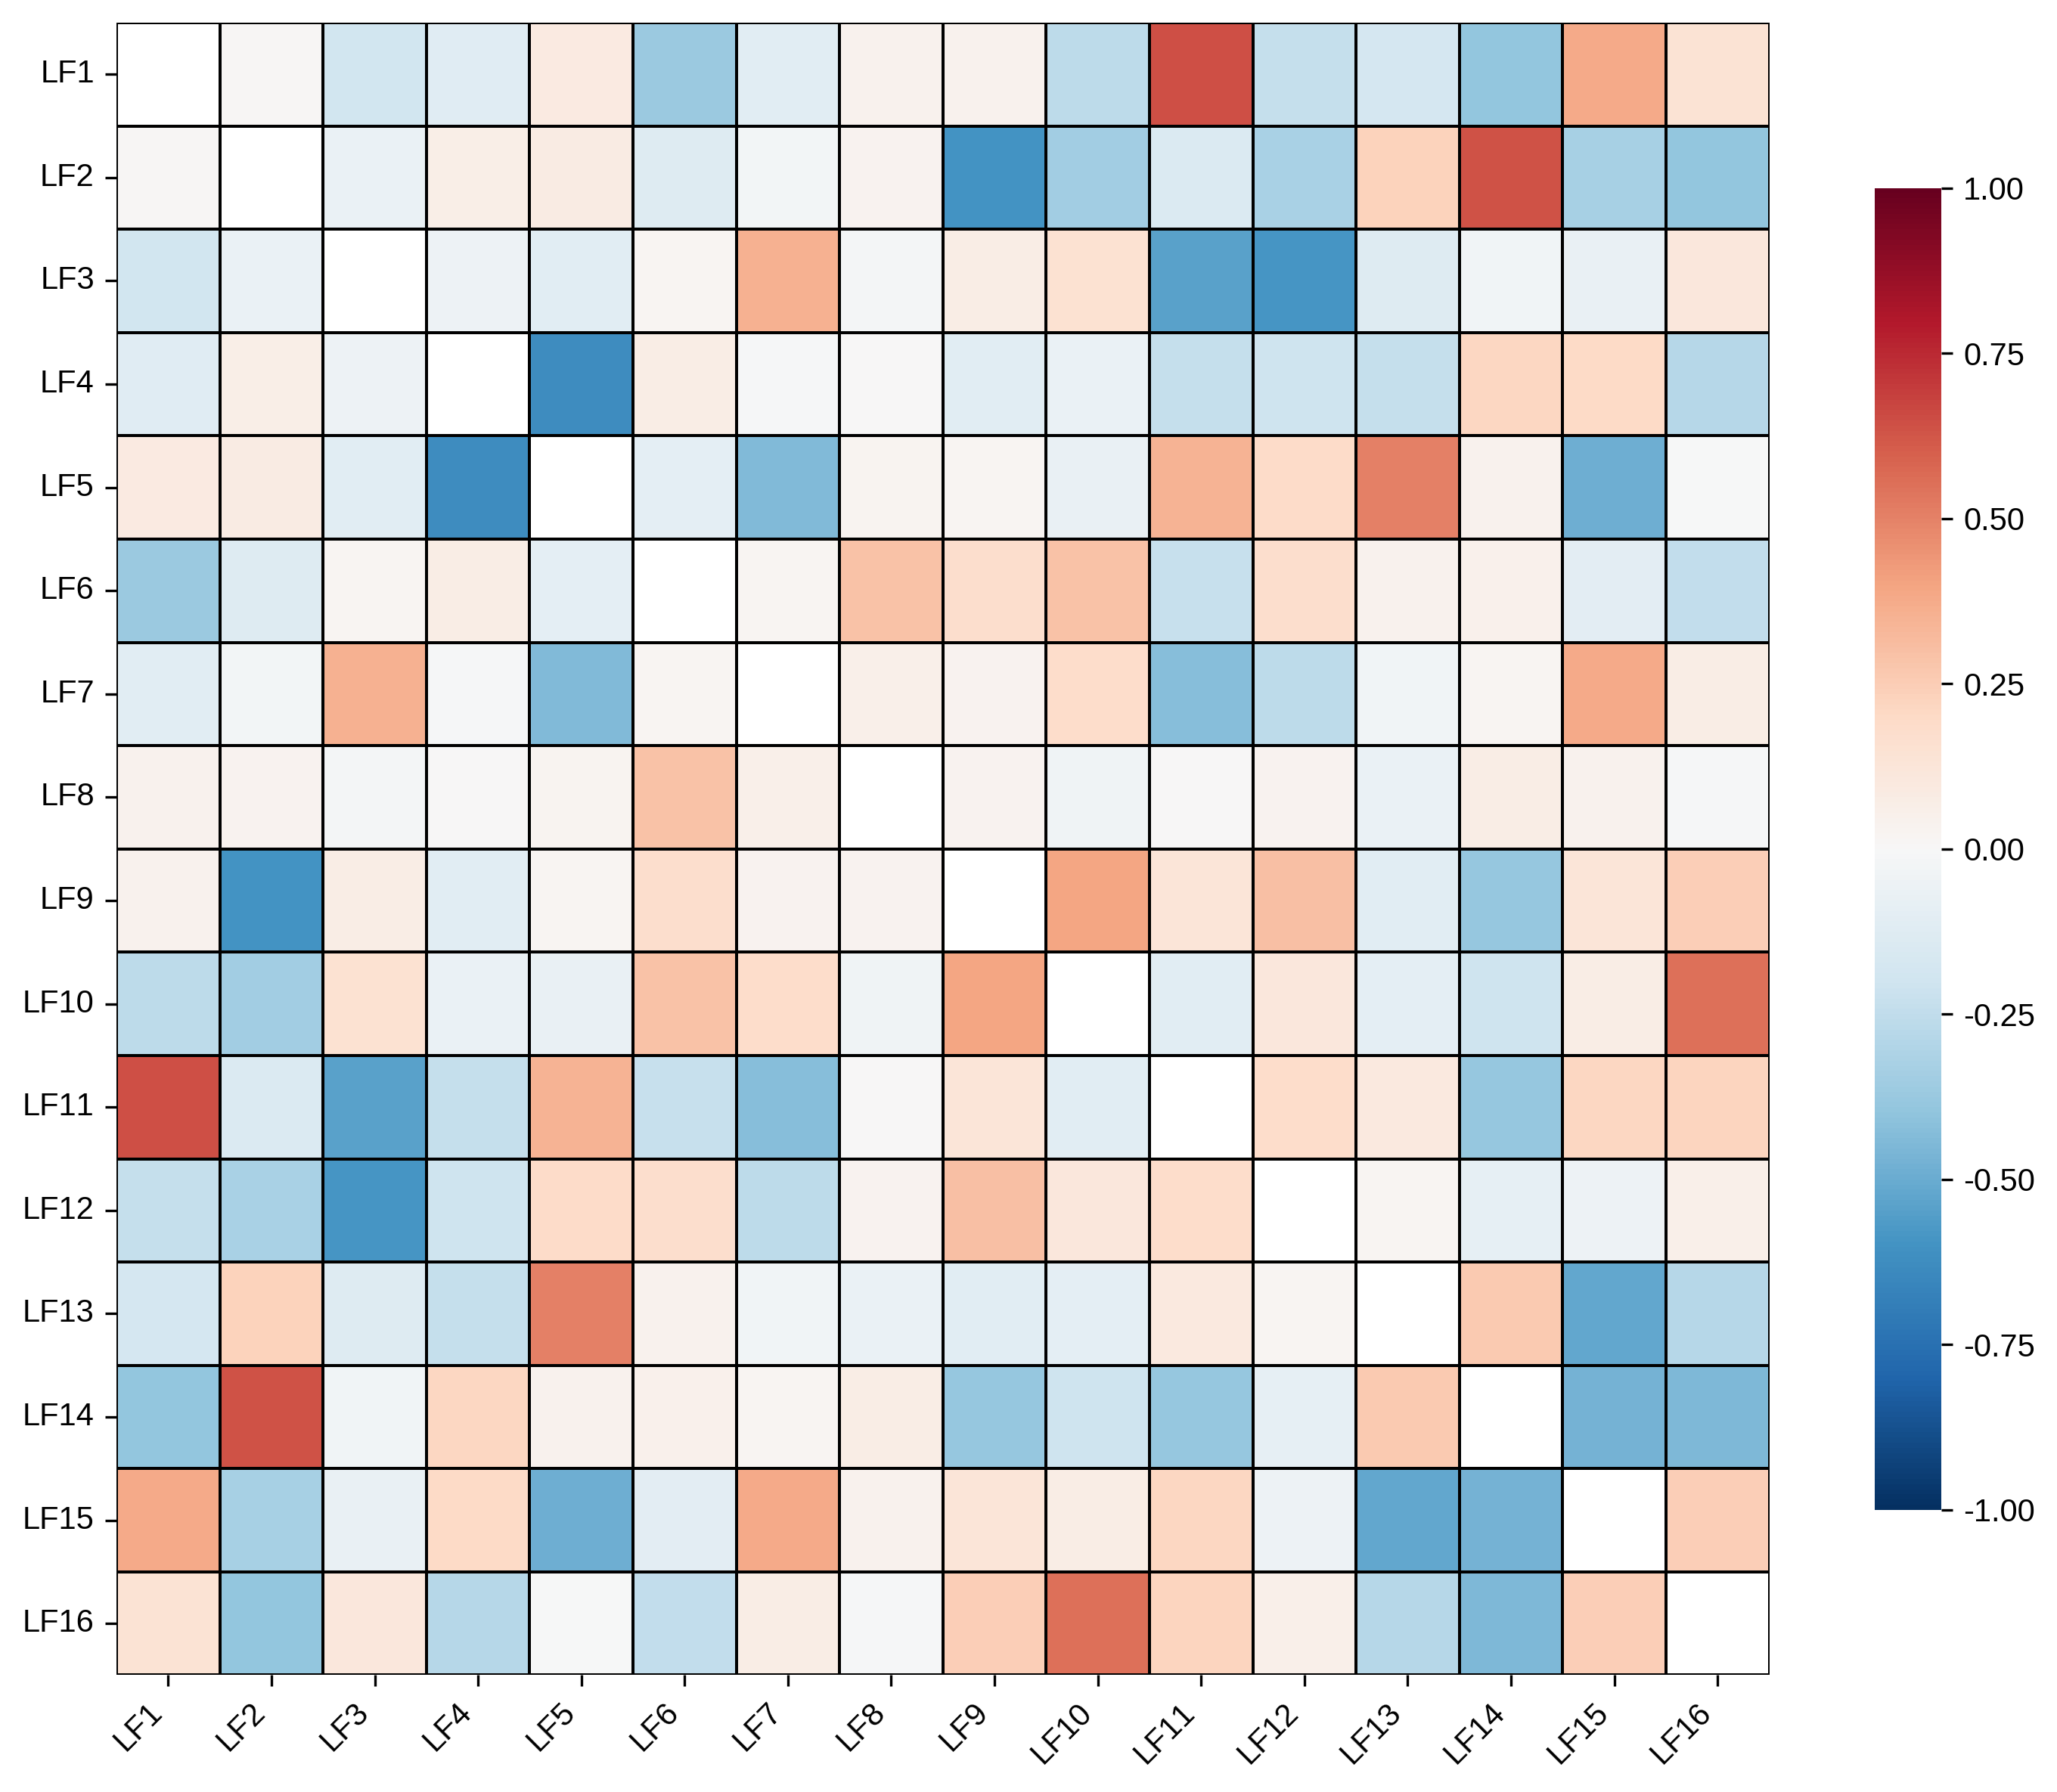

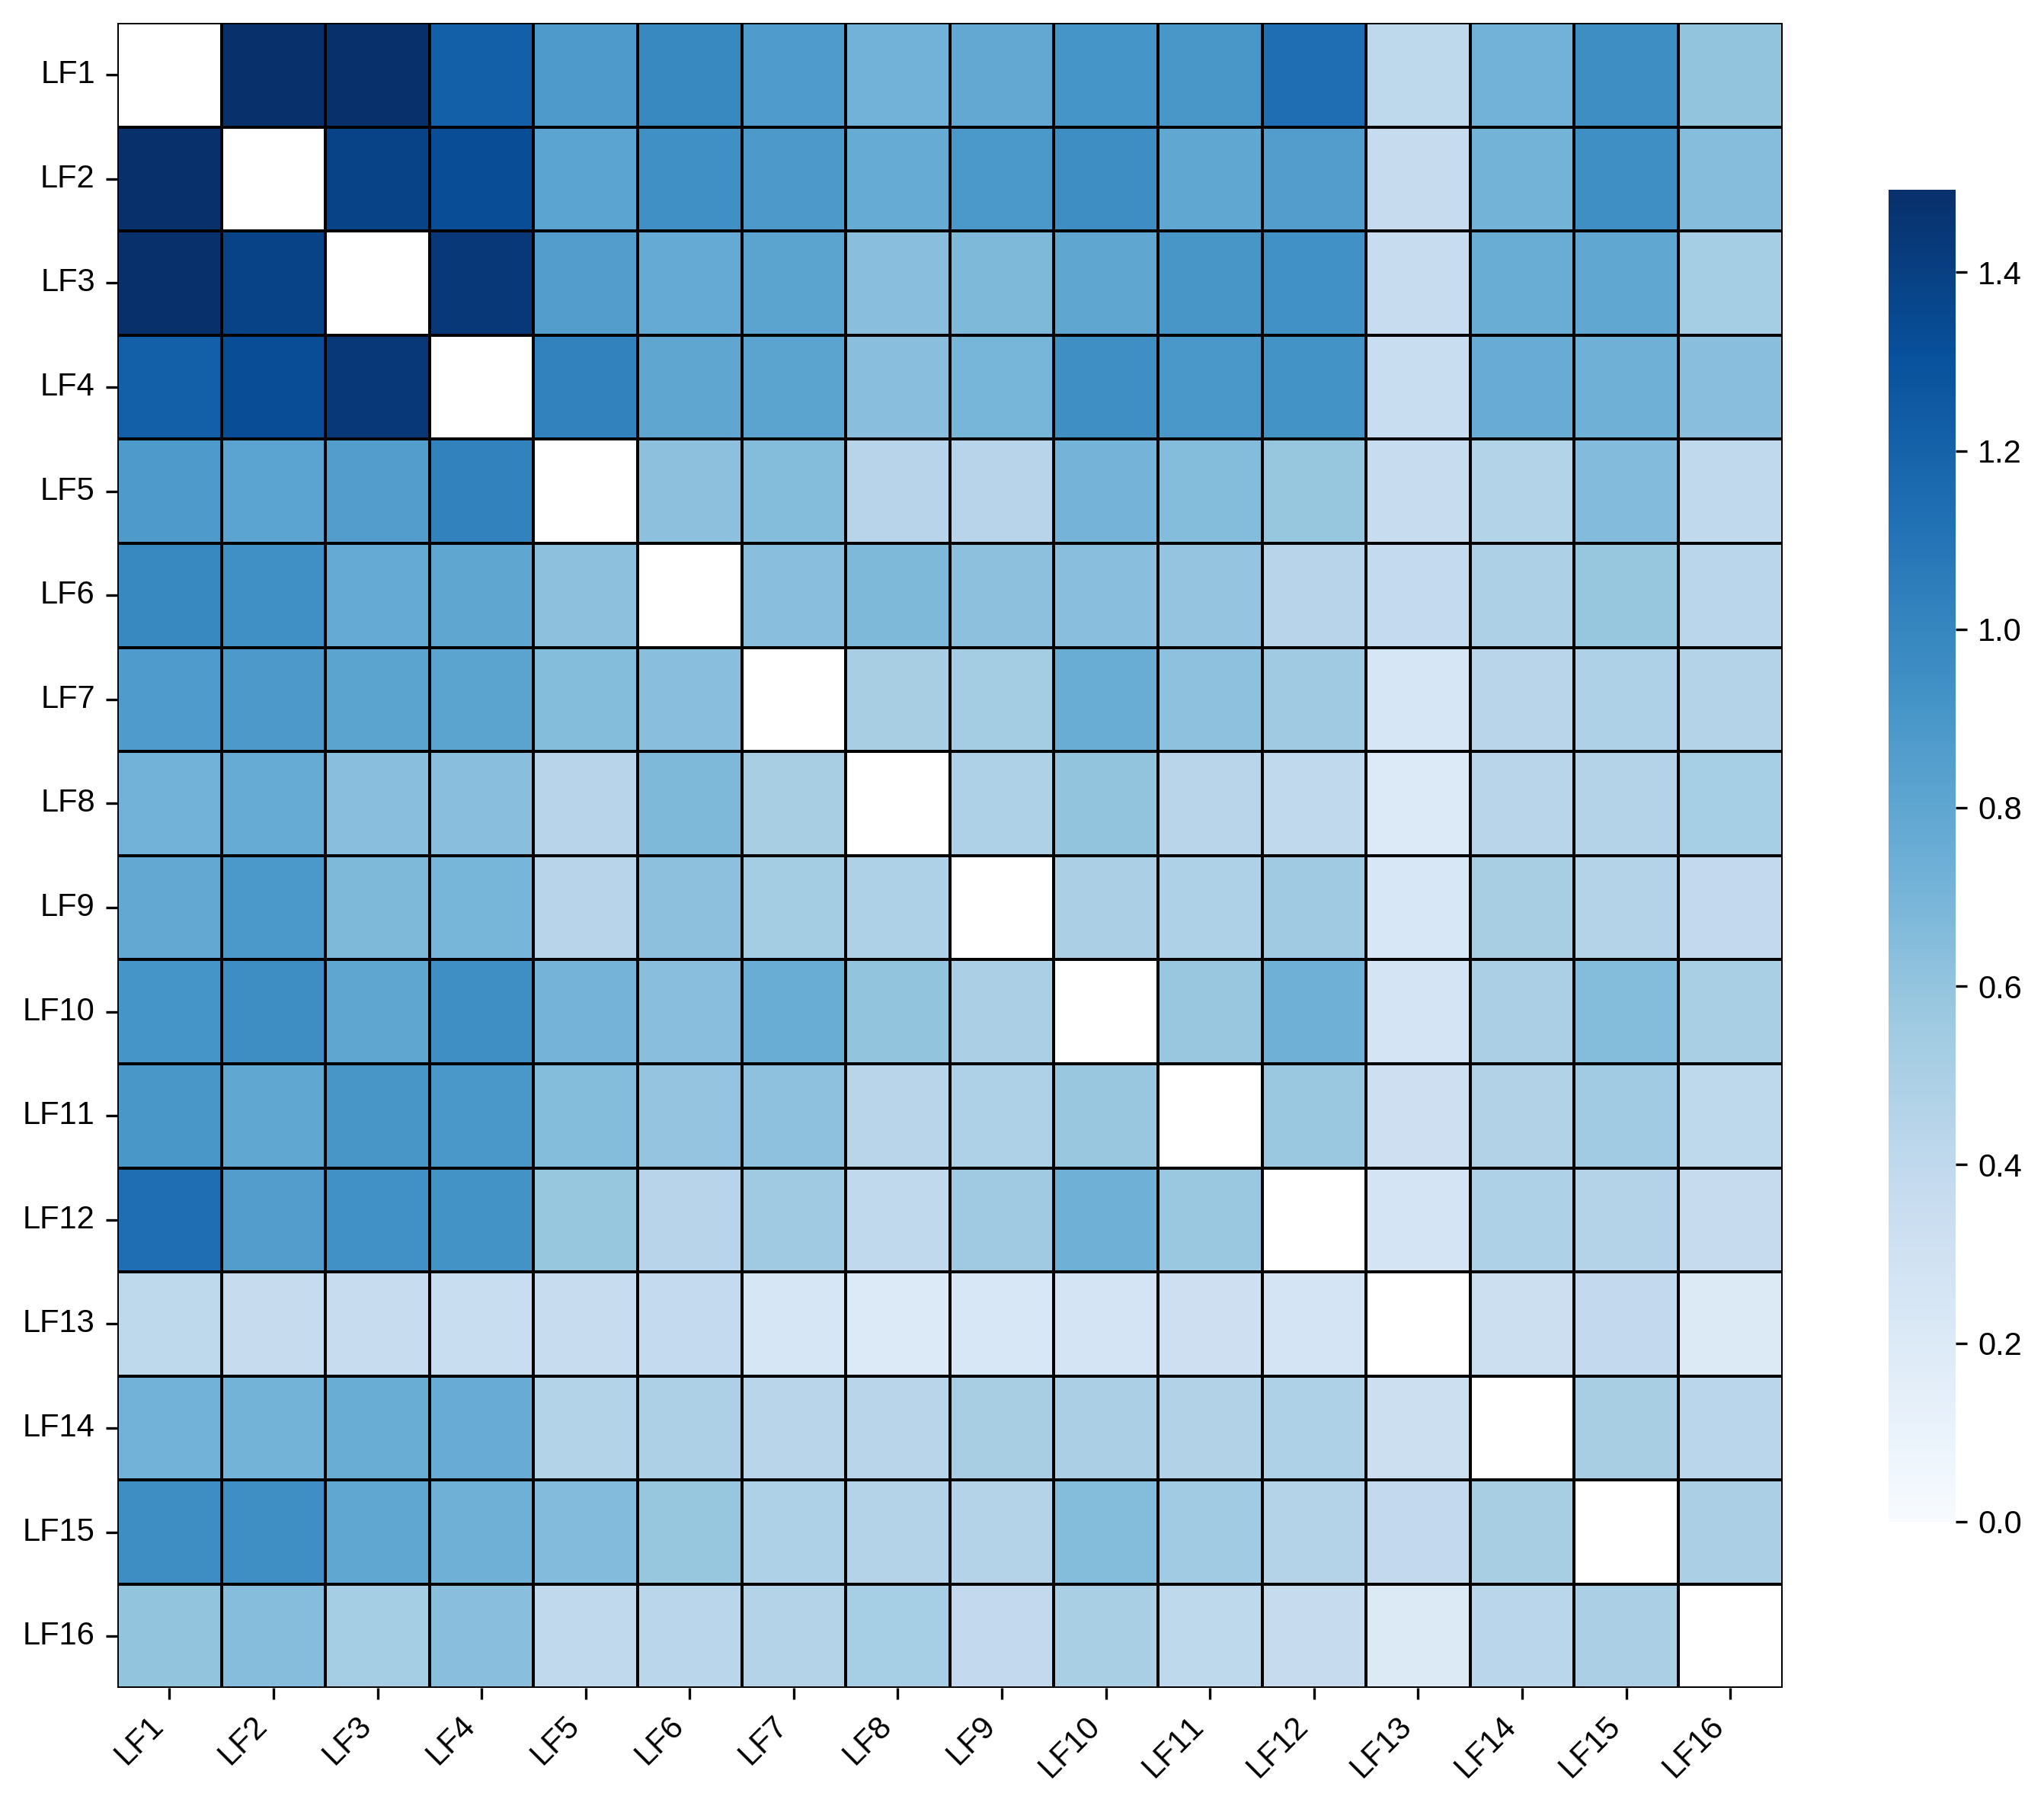

In [10]:
for method_name in latents.keys():
    if method_name == 'UMAP':
        _vmax = None
    else:
        _vmax = global_vmax
        
    mi_matrix = MIs[method_name]
    corr_matrix = corrs[method_name]

    # Correlation heatmap
    lt.corr_heatmap(
        corr_matrix=corr_matrix,
        save_path=save_path,
        method_name=method_name
    )

    # MI heatmap
    lt.MI_heatmap(
        mi_matrix=mi_matrix,
        save_path=save_path,
        method_name=method_name,
        vmax=_vmax
    )

# Average MI and corr

(<Figure size 300x300 with 1 Axes>, <Axes: ylabel='Pearson correlation'>)

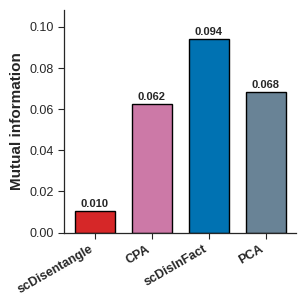

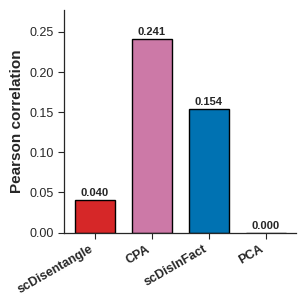

In [11]:
colors = {
    'scDisentangle': '#d62728',
    'CPA': '#CC79A7',
    'scDisInFact': '#0072B2',
    'PCA': '#698396',
    }
MIs_mean.pop('UMAP')
corrs_mean.pop('UMAP')

lt.plot_method_scores(MIs_mean, colors, metric_label="Mutual information",
                   savepath=f"{save_path}/comparison_MI.svg", dpi=600)

lt.plot_method_scores(corrs_mean, colors, metric_label="Pearson correlation",
                   savepath=f"{save_path}/comparison_corr.svg", dpi=600)

In [12]:
corrs_mean

{'scDisentangle': 0.04008021291631135,
 'CPA': 0.24119502500704998,
 'scDisInFact': 0.15438127910506005,
 'PCA': 8.402625604711939e-08}

In [13]:
MIs_mean

{'scDisentangle': 0.010400774181359236,
 'CPA': 0.062438480451213904,
 'scDisInFact': 0.09412680617689533,
 'PCA': 0.06833383039142628}